# Mixed (Gaussian-Bernoulli) RBM for Lake Plankton Community Dynamics

## Overview
The purpose of this project is to discover meaningful ecological archetypes directly from species abundance time series.

This notebook trains and interprets a Mixed Restricted Boltzmann Machine (MixedRBM) on five years of high-frequency plankton monitoring data from Lake Greifen, Switzerland (2019 to 2024).

### Notebook structure
| Section | Content |
|---|---|
| 1. Data Preparation | Dual-view encoding: binary presence + Gaussian abundance |
| 2. Train/Val Split | Chronological 80/20 split |
| 3 to 5. Model & Training | MixedRBM architecture, hyperparameter sweep, CD-1 training |
| 6. Reconstruction | Validation of learned representations |
| 7. Weight Matrices | Which species define each hidden unit |
| 8. Ecosystem States | K-means on latent space → ecological regimes |
| 9. Anomaly Analysis | Oct 2022 heatwave · Jul 2019 bloom event |

# GBRBM

### Why a Mixed (Gaussian-Bernoulli) RBM?

A standard RBM uses a single visible layer. Here we use a dual visible layer that simultaneously encodes two complementary views of the same observation:

| Channel | Variable | Meaning |
|---|---|---|
| **Binary** `Vb` | Presence/absence | *Is this taxon detected today?* |
| **Gaussian** `Vg` | Log-abundance | *How abundant is it?* |

This separation is ecologically motivated: presence and abundance carry different information.  
A rare species might be *always present* at low abundance, while a bloom species is *absent most of the time* but dominant when it appears. A single continuous channel would conflate these two regimes.

The hidden layer `h` integrates both channels via separate weight matrices $W_b$ and $W_g$, learning representations that capture both *community composition* and *community intensity*.

<img src="/Users/test/Desktop/Master/Advanced_topics_in_PoD/project_code/GBRM_diagram.png" width="600"/>

### Imports

In [3]:
from RBMS import MixedRBM
from helpers import read_data
import numpy as np
import matplotlib.pyplot as plt
from kneed import KneeLocator
from sklearn.cluster import KMeans
import pandas as pd
from sklearn.metrics import silhouette_score
import pickle
from scipy.special import softmax
rng = np.random.default_rng(42)

---
## 1. Data Preparation

### Loading the dataset

Raw data: daily counts (µL⁻¹) of 80+ plankton taxa from the Lake Greifen underwater microscope (DSPC), April 2019  to  December 2024.

**Preprocessing applied upstream (`read_data()`):**
- Drop taxa present on < 5% of days (prevalence filter)
- Drop taxa with log₁₀ standard deviation < 0.5 (variance filter: near-constant species add noise)
- Log₁₀-transform + z-score standardize the retained species → `X`
- Return raw log counts as `X_raw` and raw densities as `real_den`

In [4]:
#Load Data
X, X_raw, real_den, dates, species = read_data()
T, n_vis = X.shape
print(f"Loaded {T} time steps, {n_vis} variables")
zero_days = (real_den == 0).sum(axis=0)
zero_pct  = 100 * zero_days / T

for i, sp in enumerate(species):
    print(f"{sp:<40s}  zero days: {zero_days[i]:4d}  ({zero_pct[i]:.1f}%)")

Loaded 2066 time steps, 81 variables
aphanizomenon                             zero days:  149  (7.2%)
askenasia                                 zero days:  472  (22.8%)
asplanchna                                zero days:  300  (14.5%)
asterionella                              zero days:  348  (16.8%)
aulacoseira                               zero days:  215  (10.4%)
bosmina                                   zero days:  734  (35.5%)
centric_diatom                            zero days:   18  (0.9%)
ceratium                                  zero days:  202  (9.8%)
chaoborus                                 zero days: 1575  (76.2%)
chlorophyte                               zero days:   13  (0.6%)
chlorophyte_colonial_dividing             zero days:   13  (0.6%)
chlorophyte_elongated                     zero days:   65  (3.1%)
chlorophyte_frame                         zero days:  617  (29.9%)
chlorophyte_square                        zero days:  127  (6.1%)
chroococcales                   

---
### Constructing the dual visible layer

From the filtered dataset we construct two parallel representations of each day's community:

### 1. Data Preparation
 
Each timestep `t` has two views of the same observation:
- **`Vb[t]`**: binary presence/absence vector (`1` if detected, `0` otherwise)
- **`Vg[t]`**: Gaussian log-abundance vector (continuous, normalized counts)

Both arrays have shape `(T, n_vis)` and are always used together: every training step and every encode call receives both `Vb[t]` and `Vg[t]` for the same day `t`.

In [5]:
Vb = (real_den > 0).astype(np.float32) # Binary visibility
Vg = X                                    # Gaussian visibility

---
## 2. Train / Validation Split

**Why chronological, not random?**

Plankton communities are strongly autocorrelated: today's composition predicts tomorrow's. A random shuffle would leak future community states into the training set and give falsely optimistic validation MSE. By splitting at the 80% time point we guarantee the model is evaluated on community dynamics it has never seen.

### 2. Train/Validation Split
 
80/20 random split. Both arrays are shuffled with the same permutation so `Vb_train[i]` always pairs with `Vg_train[i]`.

The commented-out random split is kept for reference. The active split preserves temporal order: train on 2019 to 2023, validate on 2023 to 2024.

In [23]:
#random split

#perm  = rng.permutation(T)
#split = int(0.8 * T)
#Vb_train, Vb_val = Vb[perm[:split]], Vb[perm[split:]]
#Vg_train, Vg_val = Vg[perm[:split]], Vg[perm[split:]]

split = int(0.8 * T)
Vb_train, Vb_val = Vb[:split], Vb[split:]
Vg_train, Vg_val = Vg[:split], Vg[split:]



---
## 3. Model Architecture & Hyperparameters

### The MixedRBM

The model has three parameter matrices:

$$
P(h_j = 1 \mid v_b, v_g) = \sigma\!\left( (W_b\, v_b)_j + (W_g\, v_g)_j + b_{h,j} \right)
$$

$$
\mu_{v_g,i} = (W_g^\top h)_i + b_{g,i} \qquad \text{(Gaussian mean, } \sigma^2=1\text{)}
$$

| Matrix | Shape | Role |
|---|---|---|
| $W_b$ | `(n_hidden, n_vis)` | Binary channel → hidden |
| $W_g$ | `(n_hidden, n_vis)` | Gaussian channel → hidden |
| $b_h$ | `(n_hidden,)` | Hidden unit bias |
| $b_b$ | `(n_vis,)` | Binary visible bias |
| $b_g$ | `(n_vis,)` | Gaussian visible bias |

### Hyperparameters

### 3. Hyperparameters
 
| Parameter            | Value         | Role                             |
|----------------------|---------------|----------------------------------|
| `GBRBM_EPOCHS`       | 3000          | Max epochs per model             |
| `GBRBM_PATIENCE`     | 100           | Early stopping patience          |
| `RBM_LR`             | 1e-3          | Base learning rate               |
| `RBM_BATCH`          | 32            | Mini-batch size                  |
| `GBRBM_HIDDEN_SWEEP` | [5, 15, …205] | Hidden unit counts to sweep over |
 
---

The sweep tests 21 values of `n_hidden` from 5 to 205. For each model, the learning rate is scaled down as $\text{lr} = \text{RBM\_LR} / \sqrt{n_h / 5}$ to prevent instability in larger models where gradient magnitudes naturally grow.

In [24]:
GBRBM_EPOCHS        = 3000
GBRBM_PATIENCE      = 100
RBM_LR              = 1e-3
RBM_BATCH           = 32
GBRBM_HIDDEN_SWEEP  = [5, 15, 25, 35, 45, 55, 65, 75, 85, 95, 105, 115, 125, 135, 145, 155, 165, 175, 185, 195, 205]

---
## 4. Validation Metric

We evaluate reconstruction quality on the Gaussian channel only. It is a harder and more informative target. Binary presence/absence is easier to reconstruct (most species are absent most days), so using only it would give misleadingly low error.

### 4. Validation Metric: `mixed_val_mse`
 
One-step encode → decode reconstruction:
1. **Encode** [h_given_v(Vb, Vg)](cci:1://file:///Users/test/Desktop/Master/Advanced_topics_in_PoD/project_code/RBMS.py:136:4-137:61) → hidden probabilities `h`
2. **Decode** [vg_mean_given_h(h)](cci:1://file:///Users/test/Desktop/Master/Advanced_topics_in_PoD/project_code/RBMS.py:142:4-143:56) → reconstructed Gaussian visible
3. **Error** MSE between reconstruction and true `Vg`
 
Only the Gaussian channel is evaluated: the harder, more informative one.
$$
\text{MSE}_{\text{val}} = \frac{1}{T_{\text{val}}} \sum_{t=1}^{T_{\text{val}}} \frac{1}{V} \sum_{i=1}^{V} \left( v^{(t)}_{g,i} - \sigma^2 \left( W_g^\top h^{(t)} + b_g \right)_i \right)^2
$$

where $h^{(t)} = \sigma\!\left( W_b\, v^{(t)}_b + W_g\, v^{(t)}_g + b_h \right)$

 
| Symbol | Meaning |
|---|---|
| $T_{\text{val}}$ | Number of validation timesteps |
| $V$ | Number of taxa; the visible layer has size $2V$ ($V$ binary + $V$ Gaussian) |
| $v^{(t)}_{g,i}$ | True log-abundance of taxon $i$ at time $t$ |
| $v^{(t)}_b$ | Binary presence/absence vector at time $t$ |
| $v^{(t)}_g$ | Gaussian log-abundance vector at time $t$ |
| $h^{(t)}$ | Hidden unit activation probabilities at time $t$ |
| $W_b$ | Weights connecting binary visibles to hidden units |
| $W_g$ | Weights connecting Gaussian visibles to hidden units |
| $b_h$ | Hidden bias vector - shifts how easely hidden units activate |
| $b_g$ | Gaussian visible bias vector - shifts the mean of the Gaussian distribution |
| $\sigma(\cdot)$ | Element-wise sigmoid function |
| $\sigma^2$ | Fixed variance of the Gaussian visible units (here $\sigma^2 = 1$) |


The metric encodes each validation timestep using both channels, decodes back to Gaussian log-abundances, and computes mean squared error in standardized log space.

In [9]:
def mixed_val_mse(model, Vb_v, Vg_v):
    errs = [float(np.mean((Vg_v[t] - model.vg_mean_given_h(
                model.h_given_v(Vb_v[t], Vg_v[t]))) ** 2))
            for t in range(len(Vg_v))]
    return float(np.mean(errs))

---
## 5. Hidden-Unit Sweep

We train 21 models with `n_hidden` ∈ {5, 15, 25, …, 205} and track the best validation MSE for each. The goal is to find the point where adding more hidden units stops meaningfully improving reconstruction, beyond which the model overfits and interpretability degrades.

**Training algorithm: Contrastive Divergence (CD-1)**

For each training sample `(Vb[t], Vg[t])`:
1. **Positive phase**: encode to hidden probabilities `h⁺`
2. **Sample** hidden states from `h⁺`
3. **Negative phase**: decode back to visible, re-encode to `h⁻`
4. **Gradient** ≈ `outer(h⁺, v) − outer(h⁻, v_reconstructed)`

CD-1 is a biased but fast approximation to the log-likelihood gradient, standard for RBM training.

### 5. Hidden-Unit Sweep
 
The learning rate is scaled down as `lr = RBM_LR / sqrt(n_hidden / 5)` to compensate for larger gradient magnitudes in bigger models.
 
Each candidate is trained with:
- **CD-1**: one sample at a time (online within mini-batch)
- **Early stopping**: weights snapshotted on improvement, halting after 100 stale epochs

The sweep saves the best weight snapshot per model (using early stopping with patience=100) and records full training and validation histories for later inspection.

In [ ]:
# ── Sweep ─────────────────────────────────────────────────────────────────────
best_overall_val  = np.inf
best_hidden_units = None
best_model_snap   = None

sweep_results = []
for n_hidden in GBRBM_HIDDEN_SWEEP:
    lr        = RBM_LR / np.sqrt(n_hidden / 5)   # scale lr down for larger models
    rbm       = MixedRBM(n_vis, n_hidden, lr=lr, momentum=0.9, l2=1e-4)
    train_his = []
    val_his   = []
    best_val  = np.inf
    best_snap = None
    no_imp    = 0

    for epoch in range(GBRBM_EPOCHS):
        idx       = rng.permutation(len(Vb_train))
        epoch_mse = []
        for start in range(0, len(idx), RBM_BATCH):
            for t in idx[start : start + RBM_BATCH]:
                epoch_mse.append(rbm.cd1_step(Vb_train[t], Vg_train[t]))
        train_his.append(float(np.mean(epoch_mse)))

        val_mse = mixed_val_mse(rbm, Vb_val, Vg_val)
        val_his.append(val_mse)

        if val_mse < best_val:
            best_val  = val_mse
            best_snap = {k: getattr(rbm, k).copy()
                         for k in ('Wb', 'Wg', 'bb', 'bg', 'bh')}
            no_imp    = 0
        else:
            no_imp += 1
        if no_imp >= GBRBM_PATIENCE:
            break

    if best_snap:
        for k, v in best_snap.items():
            setattr(rbm, k, v)

    print(f"n_hidden={n_hidden:4d} | lr={lr:.2e} | best_val={best_val:.4f} | epochs={len(val_his)}")

    if best_val < best_overall_val:
        best_overall_val  = best_val
        best_hidden_units = n_hidden
        best_model_snap   = best_snap | {'n_hidden': n_hidden}

    sweep_results.append({
        'n_hidden': n_hidden,
        'lr': lr,
        'best_val': best_val,
        'epochs': len(val_his),
        'train_history': train_his.copy(),
        'val_history': val_his.copy(),
        'snap': best_snap
    })

In [30]:
# ── Hyperparameters ───────────────────────────────────────────────────────────
GBRBM_EPOCHS   = 1000
GBRBM_PATIENCE = 100
RBM_LR         = 1e-3
RBM_BATCH      = 32
n_hidden       = 85

best_overall_val  = np.inf
best_hidden_units = None
best_model_snap   = None

lr        = RBM_LR / np.sqrt(n_hidden / 5)
rbm       = MixedRBM(n_vis, n_hidden, lr=lr, momentum=0.9, l2=1e-4)
train_his = []
val_his   = []
best_val  = np.inf
best_snap = None
no_imp    = 0

for epoch in range(GBRBM_EPOCHS):
    idx       = rng.permutation(len(Vb_train))
    epoch_mse = []
    for start in range(0, len(idx), RBM_BATCH):
        for t in idx[start : start + RBM_BATCH]:
            epoch_mse.append(rbm.cd1_step(Vb_train[t], Vg_train[t]))
    train_his.append(float(np.mean(epoch_mse)))

    val_mse = mixed_val_mse(rbm, Vb_val, Vg_val)
    val_his.append(val_mse)

    if val_mse < best_val:
        best_val  = val_mse
        best_snap = {k: getattr(rbm, k).copy()
                     for k in ('Wb', 'Wg', 'bb', 'bg', 'bh')}
        no_imp    = 0
    else:
        no_imp += 1

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1:4d} | train={train_his[-1]:.4f} | val={val_mse:.4f} | best={best_val:.4f} | no_imp={no_imp}")

    if no_imp >= GBRBM_PATIENCE:
        print(f"Early stopping at epoch {epoch+1}")
        break

if best_snap:
    for k, v in best_snap.items():
        setattr(rbm, k, v)

rbm65       = rbm
best_snap65 = best_snap

Epoch   50 | train=0.1679 | val=0.2974 | best=0.2930 | no_imp=3
Epoch  100 | train=0.1530 | val=0.2832 | best=0.2667 | no_imp=6
Epoch  150 | train=0.1444 | val=0.2685 | best=0.2591 | no_imp=5
Epoch  200 | train=0.1407 | val=0.2553 | best=0.2497 | no_imp=5
Epoch  250 | train=0.1377 | val=0.2577 | best=0.2476 | no_imp=9
Epoch  300 | train=0.1365 | val=0.2515 | best=0.2471 | no_imp=4
Epoch  350 | train=0.1353 | val=0.2535 | best=0.2429 | no_imp=4
Epoch  400 | train=0.1342 | val=0.2463 | best=0.2429 | no_imp=54
Epoch  450 | train=0.1327 | val=0.2459 | best=0.2427 | no_imp=41
Epoch  500 | train=0.1321 | val=0.2400 | best=0.2395 | no_imp=39
Epoch  550 | train=0.1304 | val=0.2462 | best=0.2343 | no_imp=15
Epoch  600 | train=0.1291 | val=0.2459 | best=0.2341 | no_imp=33
Epoch  650 | train=0.1286 | val=0.2414 | best=0.2341 | no_imp=83
Early stopping at epoch 667


### Resuming training from best checkpoint

The best weights are restored from `best_snap65` and training continues for another `GBRBM_EPOCHS` with the same early-stopping logic. This allows extending training without losing the previously found minimum.

In [ ]:
# ── Restore best weights into rbm ─────────────────────────────────────────────
for k, v in best_snap65.items():
    setattr(rbm65, k, v)

best_val  = min(val_his)
best_snap = best_snap65
no_imp    = 0

print(f"Resuming from epoch {len(val_his)} | best_val={best_val:.4f}")

# ── Continue training ─────────────────────────────────────────────────────────
for epoch in range(GBRBM_EPOCHS):
    idx       = rng.permutation(len(Vb_train))
    epoch_mse = []
    for start in range(0, len(idx), RBM_BATCH):
        for t in idx[start : start + RBM_BATCH]:
            epoch_mse.append(rbm65.cd1_step(Vb_train[t], Vg_train[t]))
    train_his.append(float(np.mean(epoch_mse)))

    val_mse = mixed_val_mse(rbm65, Vb_val, Vg_val)
    val_his.append(val_mse)

    if val_mse < best_val:
        best_val  = val_mse
        best_snap = {k: getattr(rbm65, k).copy() for k in ('Wb', 'Wg', 'bb', 'bg', 'bh')}
        best_snap65 = best_snap
        no_imp    = 0
    else:
        no_imp += 1

    print(f"\rEpoch {epoch+1}/{GBRBM_EPOCHS} | val={val_mse:.4f} | best={best_val:.4f} | no_imp={no_imp}/{GBRBM_PATIENCE}", end='', flush=True)

    if no_imp >= GBRBM_PATIENCE:
        print(f"\nEarly stopping at epoch {len(val_his)}")
        break

for k, v in best_snap.items():
    setattr(rbm65, k, v)
print(f"\nDone | total epochs={len(val_his)} | best_val={best_val:.4f}")

Resuming from epoch 1000 | best_val=0.1865
Epoch 405/1000 | val=0.1890 | best=0.1817 | no_imp=100/100
Early stopping at epoch 1405

Done | total epochs=1405 | best_val=0.1817


### Final weight restoration

Ensures `rbm65` holds the best weights found across all training runs, not the weights from the last epoch.

In [26]:
for k in ('Wb', 'Wg', 'bb', 'bg', 'bh'):
    setattr(rbm65, k, best_snap65[k])

---
## 6. Persistence: Save / Load Sweep Results

The full sweep (21 models × training histories × weight snapshots) is serialized to disk. This avoids re-running the expensive sweep and allows downstream analysis to be run independently.

In [ ]:
with open('sweep_results.pkl', 'wb') as f:
    pickle.dump(sweep_results, f)

print(f"Saved {len(sweep_results)} sweep results.")

Saved 21 sweep results.


In [10]:
with open('sweep_results.pkl', 'rb') as f:
    sweep_results = pickle.load(f)

---
## 7. Selecting the Optimal Number of Hidden Units

The plot below shows validation MSE as a function of `n_hidden`. We expect a **diminishing returns curve**: early hidden units capture dominant community patterns (major bloom regimes, seasonal cycles), while later units model increasingly fine-grained or noisy variation.

The optimal choice is the **elbow**: the point where the marginal gain in reconstruction quality no longer justifies the loss of interpretability from adding more hidden units.

/var/folders/rq/k6q5m5x57ggcclsdrpv0g4j00000gn/T/ipykernel_15067/21471537.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=9, framealpha=0.15, labelcolor='#cccccc')


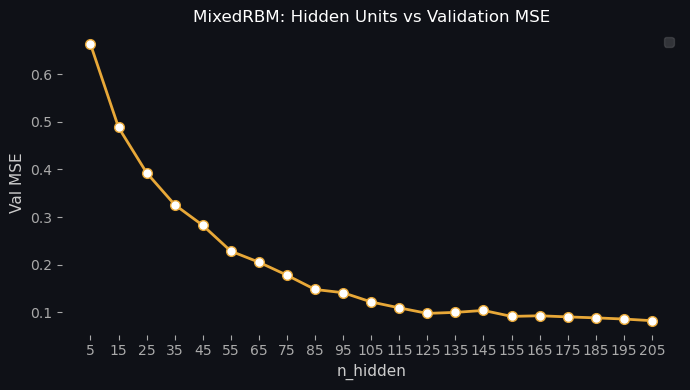

In [27]:
n_vals   = [r['n_hidden'] for r in sweep_results]
val_vals = [r['best_val'] for r in sweep_results]
 
fig, ax = plt.subplots(figsize=(7, 4), facecolor='#0f1117')
ax.set_facecolor('#0f1117')
ax.plot(n_vals, val_vals, color='#e8a838', linewidth=2, marker='o',
        markersize=7, markerfacecolor='white', markeredgecolor='#e8a838')
ax.set_xlabel('n_hidden', color='#cccccc', fontsize=11)
ax.set_ylabel('Val MSE', color='#cccccc', fontsize=11)
ax.set_title('MixedRBM: Hidden Units vs Validation MSE', color='white', fontsize=12)
ax.set_xticks(n_vals)
ax.tick_params(colors='#aaaaaa')
ax.legend(fontsize=9, framealpha=0.15, labelcolor='#cccccc')
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.show()

### Automatic elbow detection with KneeLocator

Rather than choosing the elbow by eye, we use the **KneeLocator** algorithm (Satopaa et al. 2011) to find it automatically:

### KneeLocator

1. **Normalize** $n\_hiden$ and val MSE to $[0, 1]$
2. **Fit** a smooth curve through the points
3. **Compute** the difference between the curve and the straight line connecting the first and last points
4. The **knee** is where this difference is maximized

The detected elbow gives us a principled, reproducible choice of `n_hidden` without cherry-picking.

In [12]:
kneedle = KneeLocator(n_vals, val_vals, curve="convex", direction="decreasing")
print(kneedle.elbow)

85


### Training curve for the selected model (`n_hidden = 85`)

The validation MSE curve over epochs confirms the model converges and early stopping fires at the right moment: the validation loss stops decreasing before 3000 epochs are exhausted.

/var/folders/rq/k6q5m5x57ggcclsdrpv0g4j00000gn/T/ipykernel_15067/682612178.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=9, framealpha=0.15, labelcolor='#cccccc')


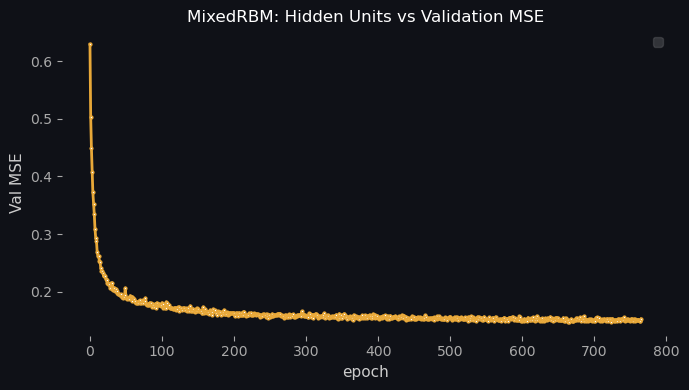

In [28]:
r65 = next(r for r in sweep_results if r['n_hidden'] == 85)
fig, ax = plt.subplots(figsize=(7, 4), facecolor='#0f1117')
ax.set_facecolor('#0f1117')
ax.plot(range(r65['epochs']), r65['val_history'], color='#e8a838', linewidth=2, marker='o',
        markersize=2, markerfacecolor='white', markeredgecolor='#e8a838')
ax.set_xlabel('epoch', color='#cccccc', fontsize=11)
ax.set_ylabel('Val MSE', color='#cccccc', fontsize=11)
ax.set_title('MixedRBM: Hidden Units vs Validation MSE', color='white', fontsize=12)
ax.tick_params(colors='#aaaaaa')
ax.legend(fontsize=9, framealpha=0.15, labelcolor='#cccccc')
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.show()

---
## 8. Reconstruction Quality: Validation Set

A trained model should be able to **reconstruct the log-abundance of each species** from its own hidden representation. We pick the 6 species with highest variance in the validation period (the most dynamic, hardest-to-reconstruct taxa) and compare observed vs reconstructed values.

Good reconstruction means the hidden layer has captured the dominant drivers of those species' dynamics.

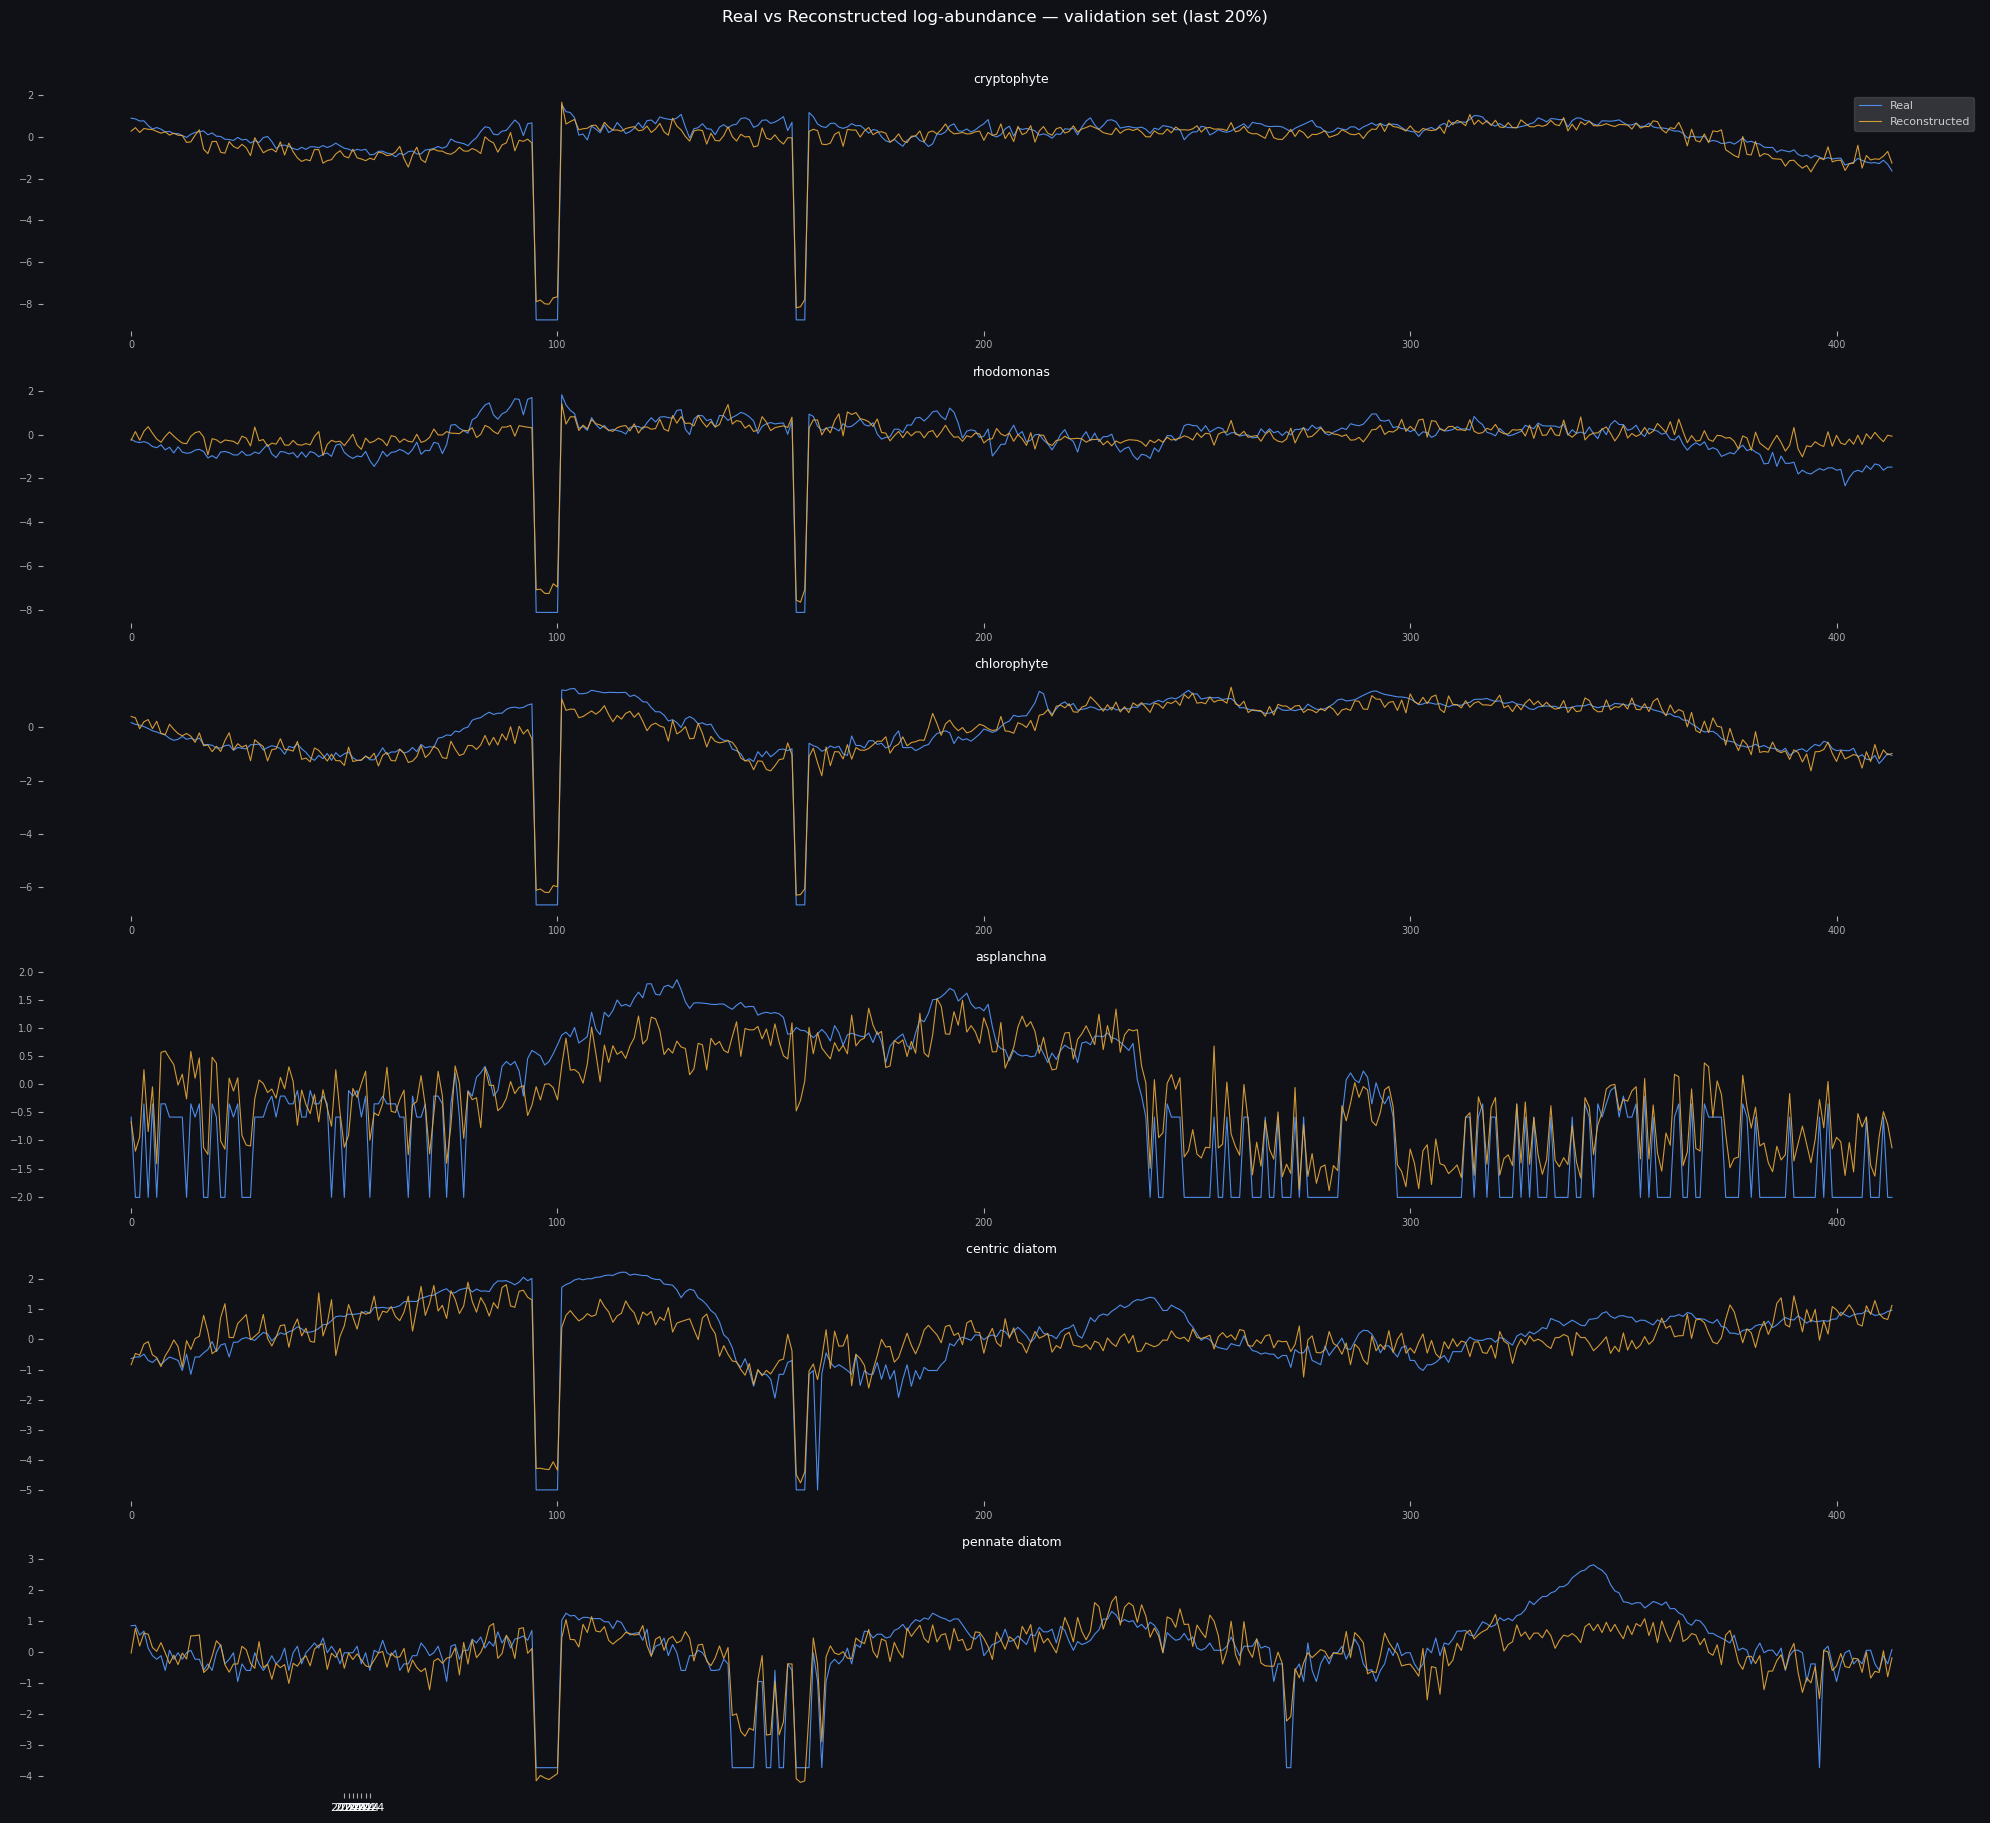

In [32]:

#rbm65 = MixedRBM(n_vis, r65['n_hidden'])
#for k in ('Wb', 'Wg', 'bb', 'bg', 'bh'):
    #setattr(rbm65, k, r65['snap'][k])

# ── Real vs Reconstructed (time order) ────────────────────────────────────────
N_SHOW = 6

Vg_rec_val = np.stack([
    rbm65.vg_mean_given_h(rbm65.h_given_v(Vb[t], Vg[t]))
    for t in range(split, T)
])

Vg_val_plot = Vg[split:]
show_idx = np.argsort(Vg_val_plot.var(axis=0))[-N_SHOW:][::-1]

fig, axes = plt.subplots(N_SHOW, 1, figsize=(20, 3 * N_SHOW), facecolor='#0f1117')
for ax, i in zip(axes, show_idx):
    ax.set_facecolor('#0f1117')
    ax.plot(Vg_val_plot[:, i], color='#5599ff', linewidth=0.8, label='Real',          alpha=0.9)
    ax.plot(Vg_rec_val[:, i],  color='#e8a838', linewidth=0.8, label='Reconstructed', alpha=0.9)
    ax.set_title(species[i].replace('_', ' '), color='white', fontsize=9)
    ax.tick_params(colors='#aaaaaa', labelsize=7)
    for spine in ax.spines.values():
        spine.set_visible(False)
    if ax is axes[0]:
        ax.legend(fontsize=8, framealpha=0.15, labelcolor='#cccccc')

jan_pos_val = [i for i, d in enumerate(pd.DatetimeIndex(dates[split:])) if d.month == 1 and d.day <= 7]
axes[-1].set_xticks(jan_pos_val)
axes[-1].set_xticklabels([str(pd.DatetimeIndex(dates[split:])[i].year) for i in jan_pos_val],
                          color='white', fontsize=8)

plt.suptitle('Real vs Reconstructed log-abundance — validation set (last 20%)', color='white', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

---
## 9. Weight Matrices: What Does Each Hidden Unit Represent?

The two weight matrices $W_b$ and $W_g$ define how each hidden unit `hⱼ` is driven by the visible community:

- **$W_b$ (presence weights):** a large positive entry means taxon `i` being *present* strongly activates hidden unit `j`
- **$W_g$ (abundance weights):** a large positive entry means taxon `i` being *abundant* strongly activates hidden unit `j`

A hidden unit that has large positive $W_b$ entries for *Daphnia* and *Cyclops* but negative entries for *Aulacoseira* is learning a **zooplankton-dominated, diatom-poor** community state: an archetype.

Divergences between $W_b$ and $W_g$ for the same taxon are informative: a taxon with high presence-weight but low abundance-weight is ecologically relevant even at low density (e.g. a keystone species or indicator taxon).

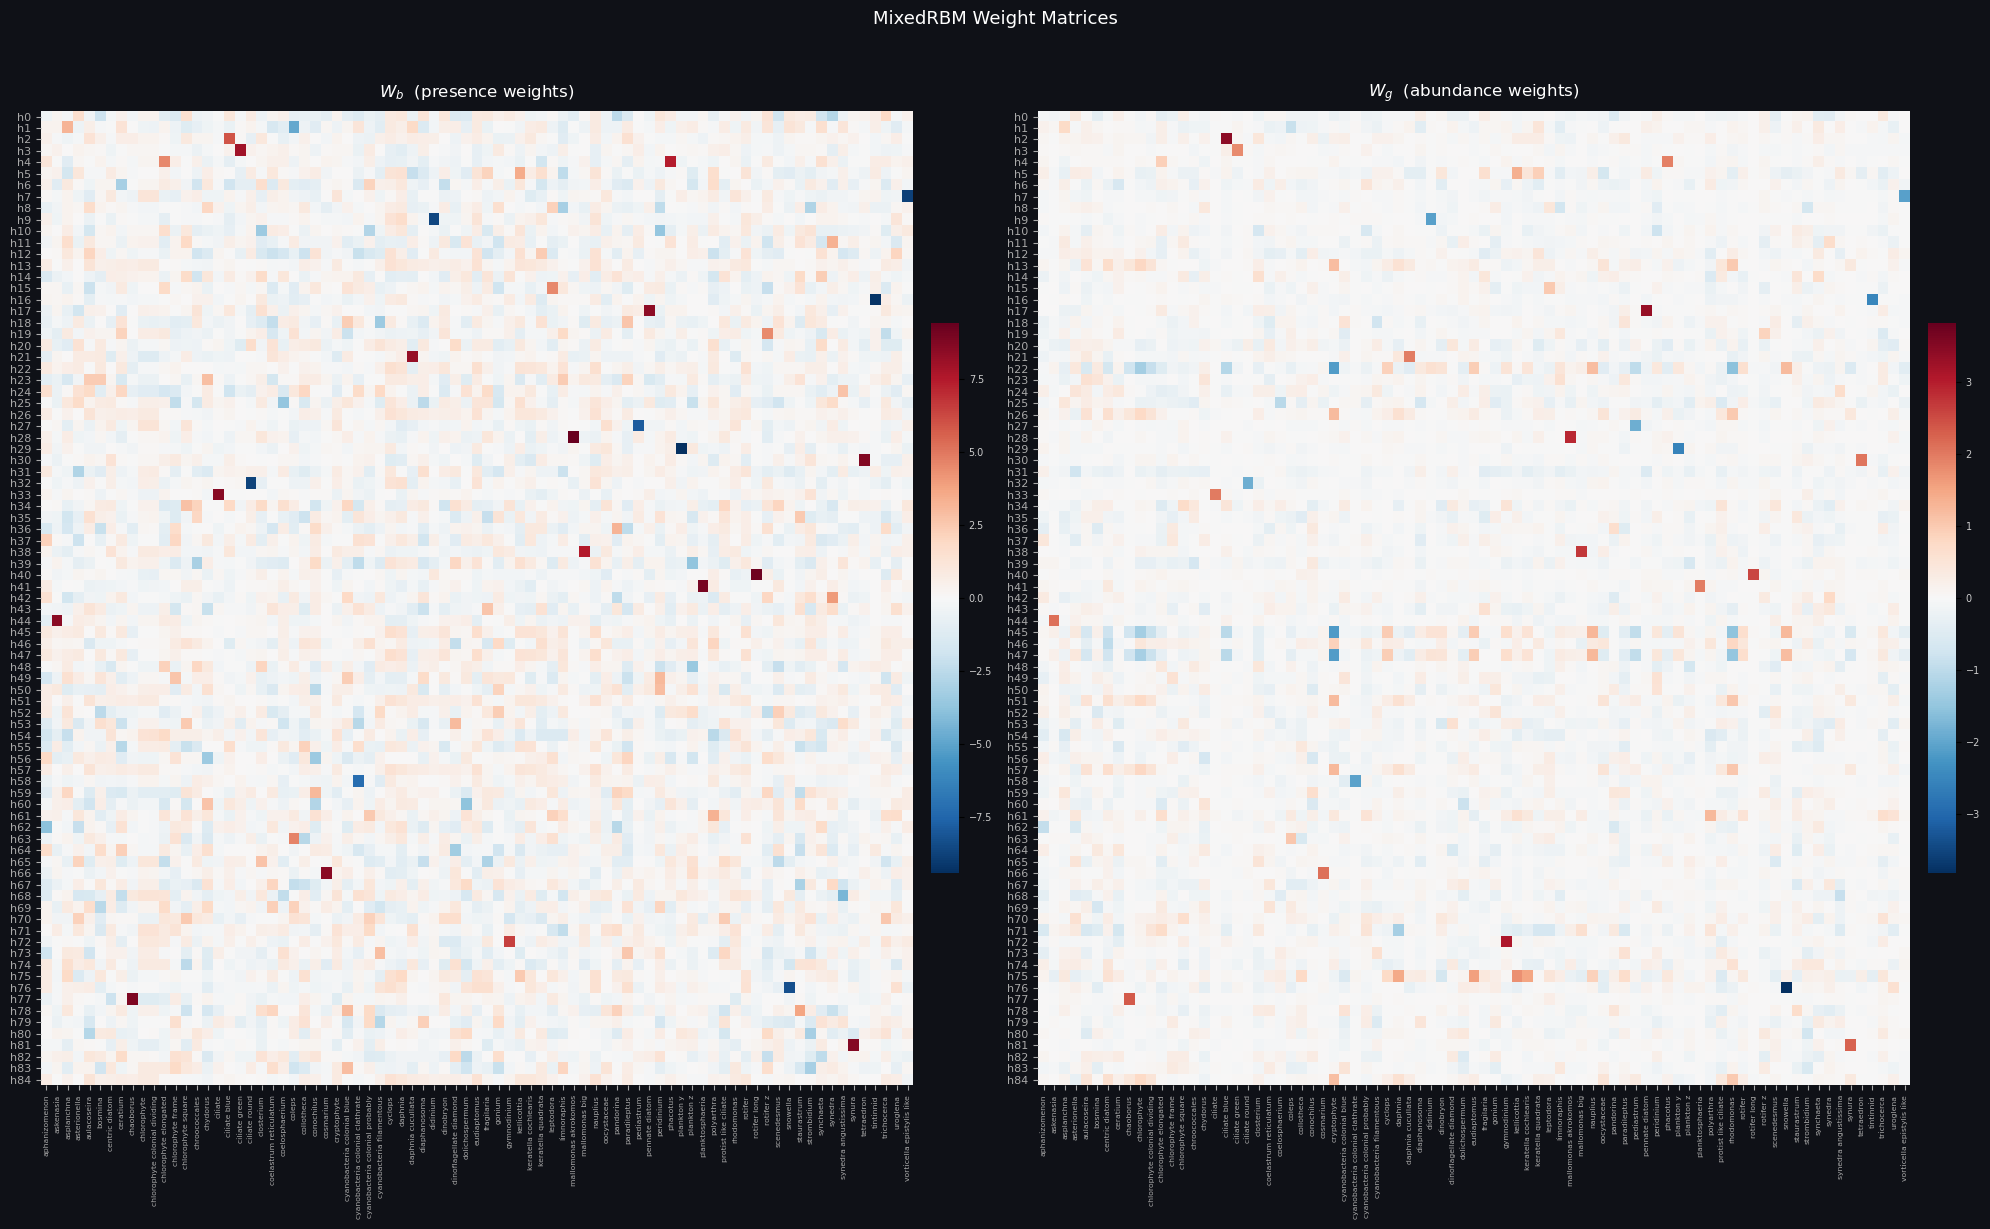

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(20, 12), facecolor='#0f1117')
sp_labels = [s.replace('_', ' ') for s in species]
 
for ax, W, title in zip(axes,
                        [r65['snap']['Wb'], r65['snap']['Wg']],
                        ['$W_b$  (presence weights)', '$W_g$  (abundance weights)']):
    ax.set_facecolor('#0f1117')
    vmax = np.abs(W).max()
    im = ax.imshow(W, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    ax.set_xticks(range(len(species)))
    ax.set_xticklabels(sp_labels, rotation=90, fontsize=5.5, color='#cccccc')
    ax.set_yticks(range(r65["n_hidden"]))
    ax.set_yticklabels([f'h{i}' for i in range(r65['n_hidden'])], fontsize=8, color='#cccccc')
    ax.set_title(title, color='white', fontsize=12, pad=10)
    cb = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
    cb.ax.yaxis.set_tick_params(labelsize=7)
    plt.setp(cb.ax.yaxis.get_ticklabels(), color='#cccccc')
    cb.outline.set_visible(False)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(colors='#aaaaaa')
 
plt.suptitle('MixedRBM Weight Matrices', color='white', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 10. Discovering Ecosystem States from the Latent Space

Each day `t` is represented as a vector `H[t]` of hidden unit activation probabilities: a **compressed fingerprint** of the community that day. Days with similar fingerprints have similar community compositions.

We cluster these fingerprints with **K-means** to find the discrete **ecosystem states** that the lake visits repeatedly.

### Choosing K: Silhouette Score

#### K-means
Cluster hidden unit vectors.

#### Silhouette score

For each point $i$:

$$s(i) = \frac{b(i) - a(i)}{\max(a(i),\ b(i))}$$

where:

- $a(i)$ = mean distance from point $i$ to all other points in its own cluster 
- $b(i)$ = mean distance from point $i$ to all points in the nearest other cluster

The overall silhouette score is the mean of $s(i)$ across all points.



The clustering runs on `H_both`: the full encoding using both channels. For ecological interpretation, each state is characterized by:
- **`state_diff`**: per-species log-abundance relative to the global mean → which taxa are enriched or depleted in that state
- **`state_season`**: seasonal composition of each state → when does the lake tend to occupy this state
- **`state_total`**: mean total plankton density in that state → is it a bloom or low-density state

Silhouette-optimal K = 2  |  Using K = 2

Ecological-state summary from RBM latent space:
State  Days  % total Dominant season  Mean total density                                                                                        Top enriched taxa
   S0  1058     51.2          Spring              0.0523                      dinoflagellate diamond, bosmina, aulacoseira, conochilus, synchaeta, centric diatom
   S1  1008     48.8          Summer              0.0665 chroococcales, coelosphaerium, dinobryon, plankton z, chlorophyte frame, cyanobacteria colonial probably


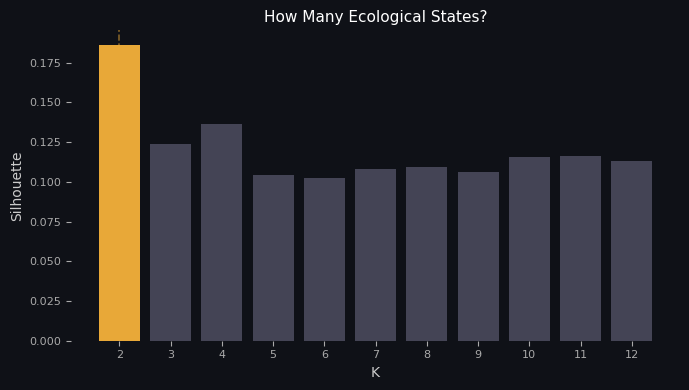

In [ ]:
#for k in ('Wb', 'Wg', 'bb', 'bg', 'bh'):
#    setattr(rbm65, k, r65['snap'][k])

H_both      = rbm65.encode(Vb, Vg)
H_presence  = np.stack([rbm65.h_given_v(Vb[t], np.zeros(n_vis, dtype=np.float32))
                        for t in range(T)])
H_abundance = np.stack([rbm65.h_given_v(np.zeros(n_vis, dtype=np.float32), Vg[t])
                        for t in range(T)])
H_list = [H_both]

X_real_log  = X_raw                                      # log10, not z-scored
rbm_species = species
dates_real  = pd.DatetimeIndex(dates)
months_real = np.array([d.month for d in dates_real])

season_map = {
    12: 'Winter',  1: 'Winter',  2: 'Winter',
     3: 'Spring',  4: 'Spring',  5: 'Spring',
     6: 'Summer',  7: 'Summer',  8: 'Summer',
     9: 'Autumn', 10: 'Autumn', 11: 'Autumn',
}

RBM_K_RANGE = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

for H_real in H_list:
    sil_scores = []
    inertias = []
    for k in RBM_K_RANGE:
        km = KMeans(n_clusters=k, random_state=42, n_init=20)
        lbl = km.fit_predict(H_real)
        sil_scores.append(silhouette_score(H_real, lbl))
        inertias.append(km.inertia_)

    auto_k   = list(RBM_K_RANGE)[int(np.argmax(sil_scores))]
    n_states = auto_k
    print(f'Silhouette-optimal K = {auto_k}  |  Using K = {n_states}')

    km_states = KMeans(n_clusters=n_states, random_state=42, n_init=20)
    rbm_state = km_states.fit_predict(H_real)
    state_H   = np.stack([H_real[rbm_state == k].mean(0) for k in range(n_states)])
    state_log = np.stack([X_real_log[rbm_state == k].mean(0) for k in range(n_states)])
    state_diff = state_log - X_real_log.mean(axis=0, keepdims=True)
    state_total = np.array([real_den[rbm_state == k].sum(axis=1).mean() for k in range(n_states)])

    season_order = ['Winter', 'Spring', 'Summer', 'Autumn']
    seasons_real = np.array([season_map[m] for m in months_real])
    state_season = np.zeros((n_states, len(season_order)), dtype=float)
    summary_rows = []
    for k in range(n_states):
        mask = rbm_state == k
        for i, s in enumerate(season_order):
            state_season[k, i] = 100 * np.mean(seasons_real[mask] == s)
        dom_season = season_order[int(np.argmax(state_season[k]))]
        top_idx = np.argsort(state_diff[k])[-6:][::-1]
        summary_rows.append({
            'State': f'S{k}',
            'Days': int(mask.sum()),
            '% total': round(100 * mask.sum() / len(rbm_state), 1),
            'Dominant season': dom_season,
            'Mean total density': round(float(state_total[k]), 4),
            'Top enriched taxa': ', '.join(rbm_species[i].replace('_', ' ') for i in top_idx),
        })

    state_df = pd.DataFrame(summary_rows)
    print('\nEcological-state summary from RBM latent space:')
    print(state_df.to_string(index=False))

    species_idx = []
    for k in range(n_states):
        species_idx.extend(np.argsort(state_diff[k])[-5:][::-1].tolist())
    species_idx = list(dict.fromkeys(species_idx))
    dom_state   = np.argmax(state_diff[:, species_idx], axis=0)
    dom_score   = state_diff[:, species_idx][dom_state, np.arange(len(species_idx))]
    order       = np.lexsort((-dom_score, dom_state))
    species_idx = [species_idx[i] for i in order]
    species_lab = [rbm_species[i].replace('_', ' ') for i in species_idx]

    PAL = plt.cm.tab10(np.linspace(0, 0.9, n_states))
    fig, ax0 = plt.subplots(figsize=(7, 4), facecolor='#0f1117')
    ax0.set_facecolor('#0f1117')

    bar_colors = ['#e8a838' if k == n_states else '#444455' for k in RBM_K_RANGE]
    ax0.bar(list(RBM_K_RANGE), sil_scores, color=bar_colors, edgecolor='none')
    ax0.axvline(n_states, color='#e8a83888', linestyle='--', linewidth=1.2)
    ax0.set_xlabel('K', color='#cccccc')
    ax0.set_ylabel('Silhouette', color='#cccccc')
    ax0.set_title('How Many Ecological States?', color='white', fontsize=11)
    ax0.set_xticks(list(RBM_K_RANGE))
    ax0.tick_params(colors='#aaaaaa', labelsize=8)
    for spine in ax0.spines.values():
        spine.set_visible(False)

    plt.tight_layout()
    plt.show()


### State composition within each season

This stacked bar chart answers: *given that it is Winter / Spring / Summer / Autumn: which ecosystem state is the lake most likely in?*

If the RBM has learned ecologically meaningful structure, states should align strongly with seasons.

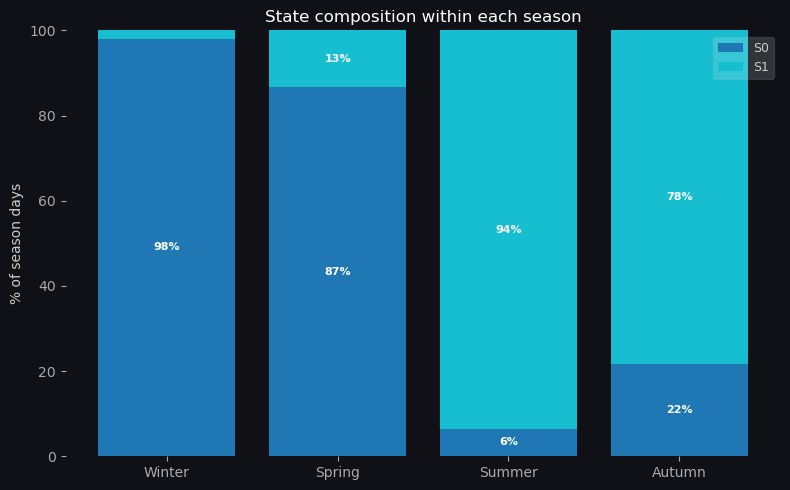

In [15]:
season_order = ['Winter', 'Spring', 'Summer', 'Autumn']
PAL = plt.cm.tab10(np.linspace(0, 0.9, n_states))

# compute: for each season, % of its days in each state
season_state = np.zeros((len(season_order), n_states), dtype=float)
for i, s in enumerate(season_order):
    season_mask = seasons_real == s
    for k in range(n_states):
        season_state[i, k] = 100 * np.mean((rbm_state == k)[season_mask])

fig, ax = plt.subplots(figsize=(8, 5), facecolor='#0f1117')
ax.set_facecolor('#0f1117')

bottom = np.zeros(len(season_order))
for k in range(n_states):
    vals = season_state[:, k]
    ax.bar(season_order, vals, bottom=bottom,
           color=PAL[k], label=f'S{k}', edgecolor='none')
    for i, (v, b) in enumerate(zip(vals, bottom)):
        if v > 6:
            ax.text(i, b + v/2, f'{v:.0f}%', ha='center', va='center',
                    fontsize=8, color='white', fontweight='bold')
    bottom += vals

ax.set_ylabel('% of season days', color='#cccccc', fontsize=10)
ax.set_title('State composition within each season', color='white', fontsize=12)
ax.legend(loc='upper right', fontsize=9, framealpha=0.15, labelcolor='#cccccc')
ax.tick_params(colors='#aaaaaa')
ax.set_ylim(0, 100)
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.show()

### State composition within each calendar month

A finer-grained view than seasons. This reveals **transition months** (e.g. May, October) where the lake shifts rapidly between states, and **locked months** (e.g. July, January) that are almost exclusively one state.

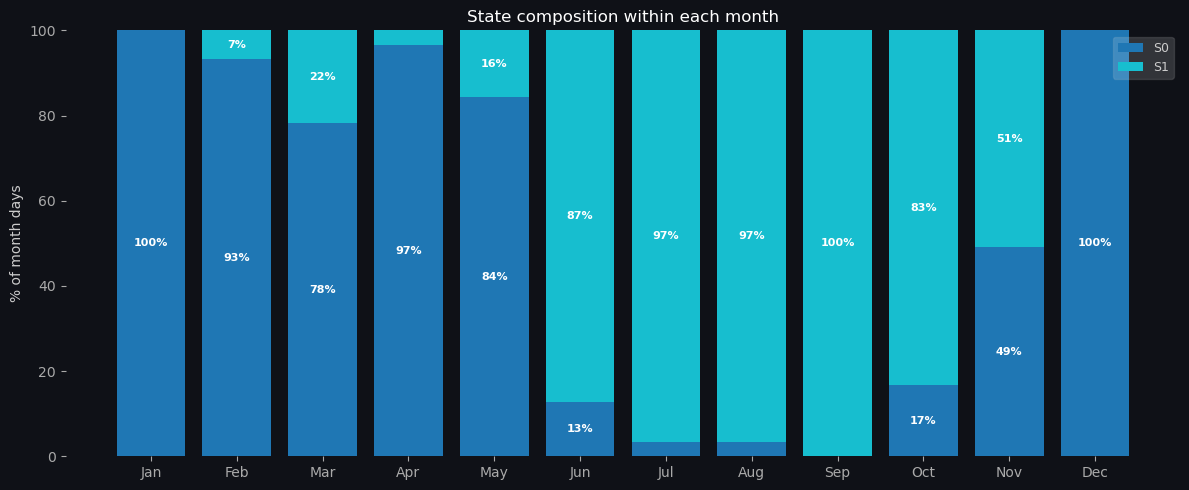

In [16]:
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
months_real = np.array([d.month for d in dates_real])

# for each month, % of its days in each state
month_state = np.zeros((12, n_states), dtype=float)
for i, m in enumerate(range(1, 13)):
    month_mask = months_real == m
    for k in range(n_states):
        month_state[i, k] = 100 * np.mean((rbm_state == k)[month_mask])

fig, ax = plt.subplots(figsize=(12, 5), facecolor='#0f1117')
ax.set_facecolor('#0f1117')

bottom = np.zeros(12)
for k in range(n_states):
    vals = month_state[:, k]
    ax.bar(month_names, vals, bottom=bottom,
           color=PAL[k], label=f'S{k}', edgecolor='none')
    for i, (v, b) in enumerate(zip(vals, bottom)):
        if v > 6:
            ax.text(i, b + v/2, f'{v:.0f}%', ha='center', va='center',
                    fontsize=8, color='white', fontweight='bold')
    bottom += vals

ax.set_ylabel('% of month days', color='#cccccc', fontsize=10)
ax.set_title('State composition within each month', color='white', fontsize=12)
ax.legend(loc='upper right', fontsize=9, framealpha=0.15, labelcolor='#cccccc')
ax.tick_params(colors='#aaaaaa')
ax.set_ylim(0, 100)
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.show()

### Soft state membership over time

K-means assigns each day to exactly one state (hard assignment). But real ecological transitions are gradual. We compute **soft membership** by applying a softmax over the negative distances to each cluster centroid:

$$
p(k \mid t) = \frac{\exp(-d(H_t, \mu_k) / \tau)}{\sum_{k'} \exp(-d(H_t, \mu_{k'}) / \tau)}
$$

where $\tau$ is a temperature parameter controlling sharpness. Low $\tau$ → near-hard assignments; high $\tau$ → diffuse, uncertain assignments.

The resulting time series shows **when the lake is confidently in one state** vs when it is transitioning between states.

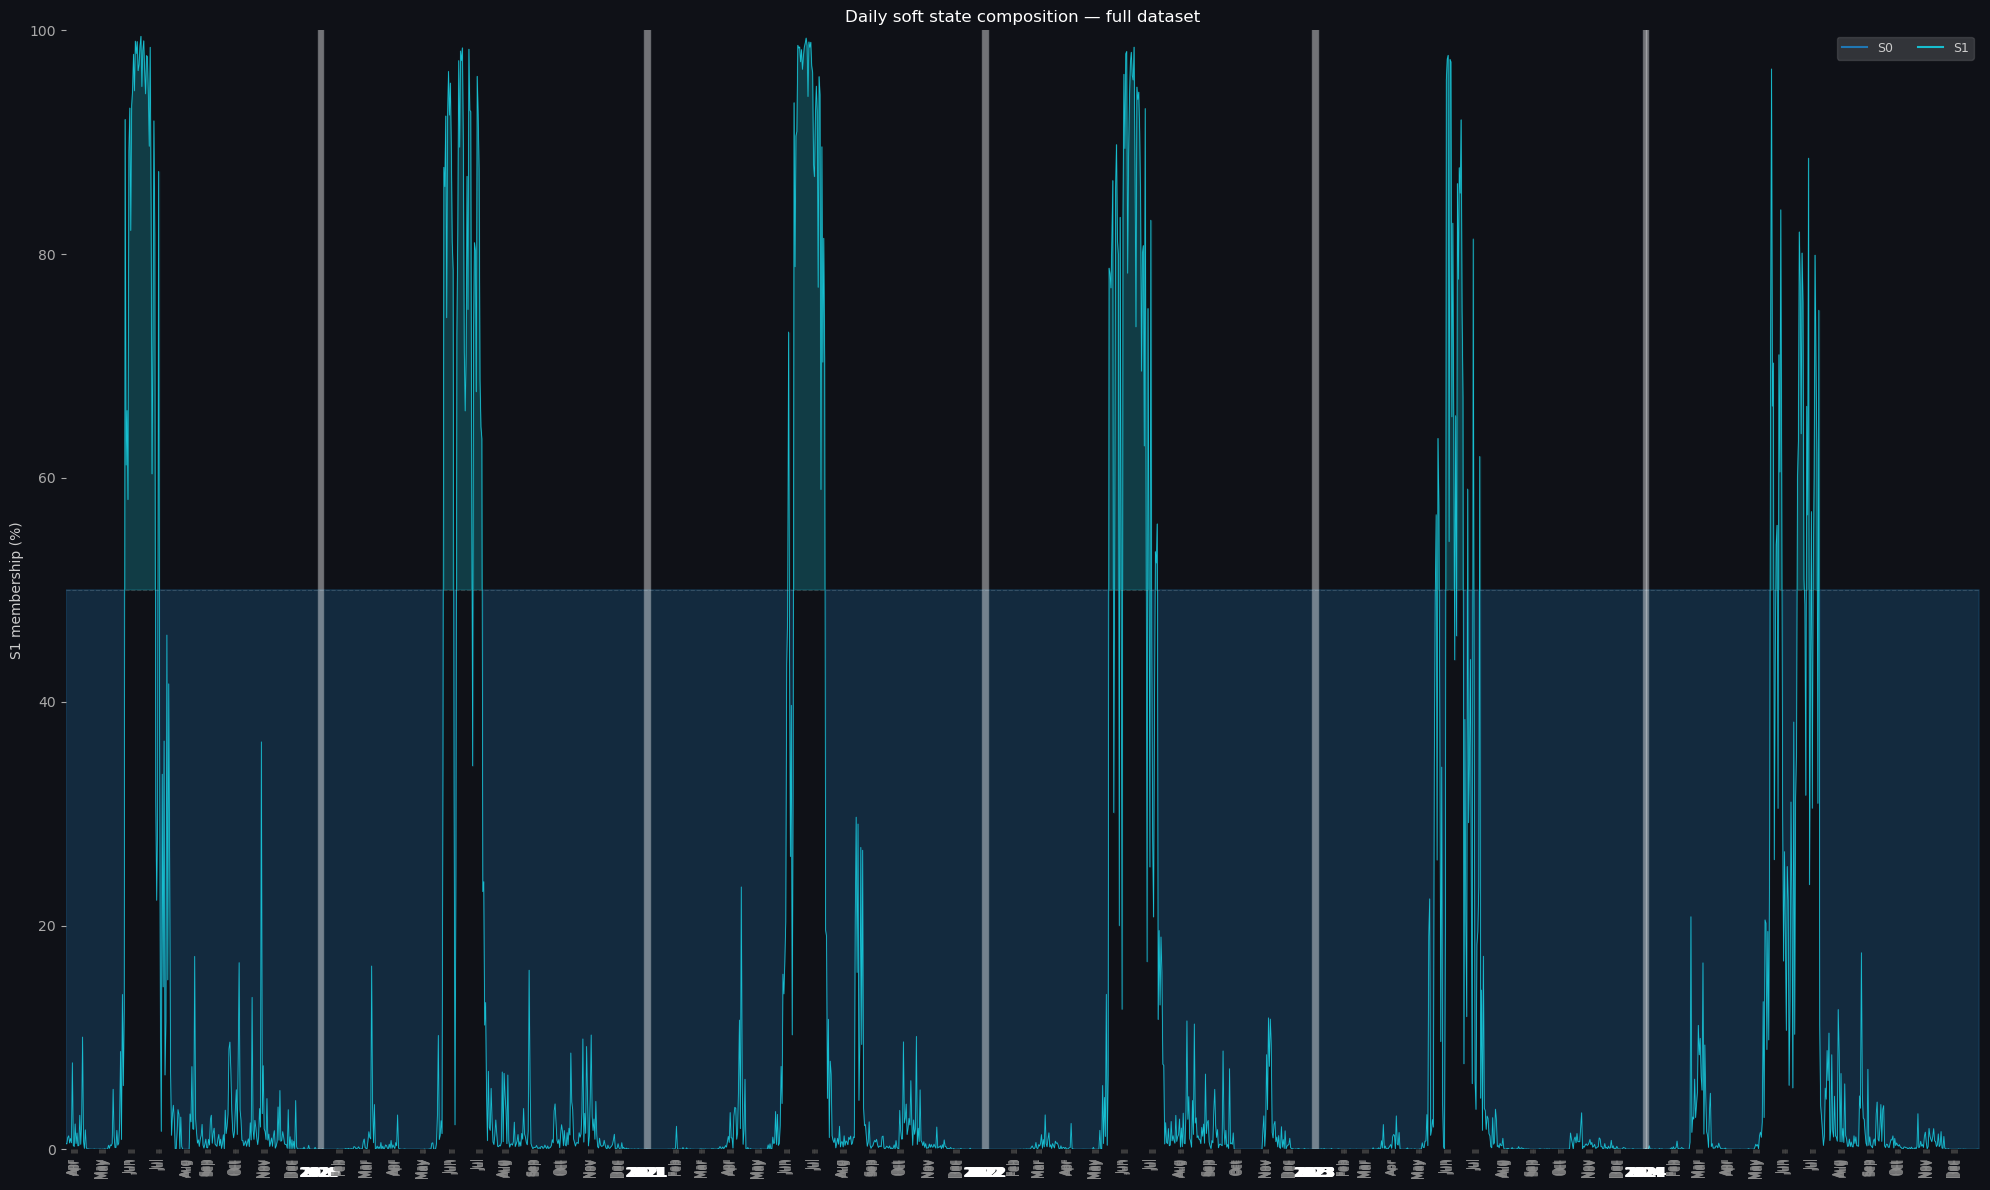

In [17]:
dists       = km.transform(H_both)
temperature = 0.1
soft_probs  = softmax(-dists / (dists.std() * temperature), axis=1)

day_idx = np.arange(len(dates_real))

fig, ax = plt.subplots(figsize=(20, 12), facecolor='#0f1117')
ax.set_facecolor('#0f1117')

ax.plot(day_idx, 100 * soft_probs[:, 1], color=PAL[1], linewidth=0.6)
ax.axhline(50, color='#ffffff22', linewidth=0.8, linestyle='--')
ax.fill_between(day_idx, 50, 100 * soft_probs[:, 1],
                where=(soft_probs[:, 1] > 0.5), color=PAL[1], alpha=0.25)
ax.fill_between(day_idx, 100 * soft_probs[:, 1], 50,
                where=(soft_probs[:, 1] < 0.5), color=PAL[0], alpha=0.25)

# ── Year lines + labels ───────────────────────────────────────────────────────
jan_pos = [i for i, d in enumerate(dates_real) if d.month == 1 and d.day <= 7]
for xi in jan_pos:
    ax.axvline(xi, color='#ffffff55', linewidth=1.0)
ax.set_xticks(jan_pos)
ax.set_xticklabels([str(dates_real[i].year) for i in jan_pos],
                   color='white', fontsize=10, fontweight='bold')

# ── Month tick marks + labels ─────────────────────────────────────────────────
mon_pos = [i for i, d in enumerate(dates_real) if d.day <= 7 and d.month != 1]
mon_lbl = [dates_real[i].strftime('%b') for i in mon_pos]
ax.set_xticks(mon_pos, minor=True)
ax.set_xticklabels(mon_lbl, minor=True, color='#888888', fontsize=7, rotation=90)
ax.tick_params(axis='x', which='minor', length=3, color='#444444')
ax.tick_params(axis='x', which='major', length=0, pad=12)

ax.set_ylabel('S1 membership (%)', color='#cccccc', fontsize=10)
ax.set_title('Daily soft state composition — full dataset', color='white', fontsize=12)
ax.legend(handles=[plt.Line2D([0],[0], color=PAL[k], label=f'S{k}') for k in range(n_states)],
          fontsize=9, framealpha=0.15, labelcolor='#cccccc', ncol=n_states)
ax.set_ylim(0, 100)
ax.set_xlim(0, len(dates_real))
ax.tick_params(axis='y', colors='#aaaaaa')
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.show()

---
## 11. Extended Clustering Analysis

Re-encoding the full dataset and running a fresh silhouette sweep with a redefined K range (3 to 12) to explore other numbers of states and re-derive the state assignments for the ecological interpretation below.

Silhouette-optimal K = 4  |  Using K = 4


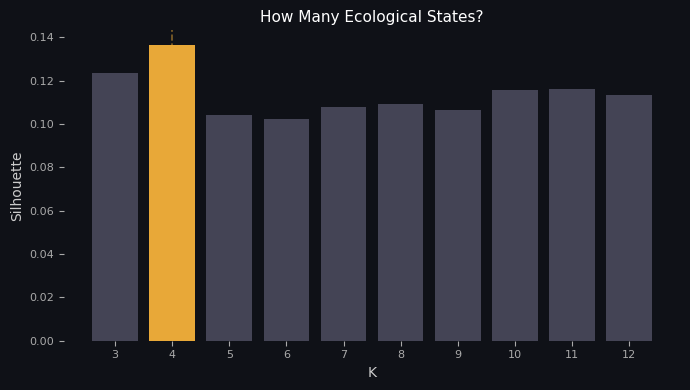

In [16]:
rbm65 = MixedRBM(n_vis, r65['n_hidden'])
#for k in ('Wb', 'Wg', 'bb', 'bg', 'bh'):
#    setattr(rbm65, k, r65['snap'][k])

H_both      = rbm65.encode(Vb, Vg)
H_presence  = np.stack([rbm65.h_given_v(Vb[t], np.zeros(n_vis, dtype=np.float32))
                        for t in range(T)])
H_abundance = np.stack([rbm65.h_given_v(np.zeros(n_vis, dtype=np.float32), Vg[t])
                        for t in range(T)])
H_list = [H_both]

X_real_log  = X_raw                                      # log10, not z-scored
rbm_species = species
dates_real  = pd.DatetimeIndex(dates)
months_real = np.array([d.month for d in dates_real])

season_map = {
    12: 'Winter',  1: 'Winter',  2: 'Winter',
     3: 'Spring',  4: 'Spring',  5: 'Spring',
     6: 'Summer',  7: 'Summer',  8: 'Summer',
     9: 'Autumn', 10: 'Autumn', 11: 'Autumn',
}

RBM_K_RANGE = [3,4, 5, 6, 7, 8, 9, 10, 11, 12]

for H_real in H_list:
    sil_scores = []
    inertias = []
    for k in RBM_K_RANGE:
        km = KMeans(n_clusters=k, random_state=42, n_init=20)
        lbl = km.fit_predict(H_real)
        sil_scores.append(silhouette_score(H_real, lbl))
        inertias.append(km.inertia_)

    auto_k   = list(RBM_K_RANGE)[int(np.argmax(sil_scores))]
    n_states = auto_k
    print(f'Silhouette-optimal K = {auto_k}  |  Using K = {n_states}')

    km_states = KMeans(n_clusters=n_states, random_state=42, n_init=20)
    rbm_state = km_states.fit_predict(H_real)
    state_H   = np.stack([H_real[rbm_state == k].mean(0) for k in range(n_states)])
    state_log = np.stack([X_real_log[rbm_state == k].mean(0) for k in range(n_states)])
    state_diff = state_log - X_real_log.mean(axis=0, keepdims=True)
    state_total = np.array([real_den[rbm_state == k].sum(axis=1).mean() for k in range(n_states)])

    season_order = ['Winter', 'Spring', 'Summer', 'Autumn']
    seasons_real = np.array([season_map[m] for m in months_real])
    state_season = np.zeros((n_states, len(season_order)), dtype=float)
    summary_rows = []
    for k in range(n_states):
        mask = rbm_state == k
        for i, s in enumerate(season_order):
            state_season[k, i] = 100 * np.mean(seasons_real[mask] == s)
        dom_season = season_order[int(np.argmax(state_season[k]))]
        top_idx = np.argsort(state_diff[k])[-6:][::-1]
        summary_rows.append({
            'State': f'S{k}',
            'Days': int(mask.sum()),
            '% total': round(100 * mask.sum() / len(rbm_state), 1),
            'Dominant season': dom_season,
            'Mean total density': round(float(state_total[k]), 4),
            'Top enriched taxa': ', '.join(rbm_species[i].replace('_', ' ') for i in top_idx),
        })

    state_df = pd.DataFrame(summary_rows)

    species_idx = []
    for k in range(n_states):
        species_idx.extend(np.argsort(state_diff[k])[-5:][::-1].tolist())
    species_idx = list(dict.fromkeys(species_idx))
    dom_state   = np.argmax(state_diff[:, species_idx], axis=0)
    dom_score   = state_diff[:, species_idx][dom_state, np.arange(len(species_idx))]
    order       = np.lexsort((-dom_score, dom_state))
    species_idx = [species_idx[i] for i in order]
    species_lab = [rbm_species[i].replace('_', ' ') for i in species_idx]

    PAL = plt.cm.tab10(np.linspace(0, 0.9, n_states))
    fig, ax0 = plt.subplots(figsize=(7, 4), facecolor='#0f1117')
    ax0.set_facecolor('#0f1117')

    bar_colors = ['#e8a838' if k == n_states else '#444455' for k in RBM_K_RANGE]
    ax0.bar(list(RBM_K_RANGE), sil_scores, color=bar_colors, edgecolor='none')
    ax0.axvline(n_states, color='#e8a83888', linestyle='--', linewidth=1.2)
    ax0.set_xlabel('K', color='#cccccc')
    ax0.set_ylabel('Silhouette', color='#cccccc')
    ax0.set_title('How Many Ecological States?', color='white', fontsize=11)
    ax0.set_xticks(list(RBM_K_RANGE))
    ax0.tick_params(colors='#aaaaaa', labelsize=8)
    for spine in ax0.spines.values():
        spine.set_visible(False)

    plt.tight_layout()
    plt.show()

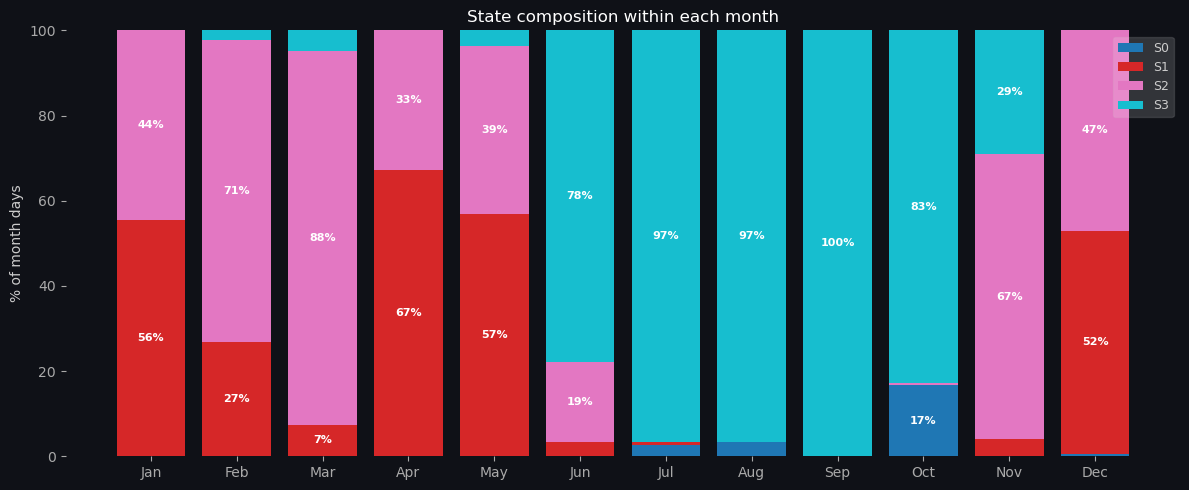

   Season  S0 (%)  S1 (%)  S2 (%)  S3 (%)
0     Jan     0.0    55.6    44.4     0.0
1     Feb     0.0    26.9    70.9     2.2
2     Mar     0.0     7.5    87.6     5.0
3     Apr     0.0    67.2    32.8     0.0
4     May     0.0    57.0    39.2     3.8
5     Jun     0.0     3.3    18.9    77.8
6     Jul     2.7     0.5     0.0    96.7
7     Aug     3.4     0.0     0.0    96.6
8     Sep     0.0     0.0     0.0   100.0
9     Oct    16.7     0.0     0.5    82.8
10    Nov     0.0     4.0    66.9    29.1
11    Dec     0.5    52.5    47.0     0.0


In [17]:
PAL = plt.cm.tab10(np.linspace(0, 0.9, n_states))
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
months_real = np.array([d.month for d in dates_real])

# for each month, % of its days in each state
month_state = np.zeros((12, n_states), dtype=float)
rows = []
for i, m in enumerate(range(1, 13)):
    month_mask = months_real == m
    for k in range(n_states):
        month_state[i, k] = 100 * np.mean((rbm_state == k)[month_mask])

fig, ax = plt.subplots(figsize=(12, 5), facecolor='#0f1117')
ax.set_facecolor('#0f1117')

bottom = np.zeros(12)
for k in range(n_states):
    vals = month_state[:, k]
    ax.bar(month_names, vals, bottom=bottom,
           color=PAL[k], label=f'S{k}', edgecolor='none')
    for i, (v, b) in enumerate(zip(vals, bottom)):
        if v > 6:
            ax.text(i, b + v/2, f'{v:.0f}%', ha='center', va='center',
                    fontsize=8, color='white', fontweight='bold')
    bottom += vals

ax.set_ylabel('% of month days', color='#cccccc', fontsize=10)
ax.set_title('State composition within each month', color='white', fontsize=12)
ax.legend(loc='upper right', fontsize=9, framealpha=0.15, labelcolor='#cccccc')
ax.tick_params(colors='#aaaaaa')
ax.set_ylim(0, 100)
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.show()
for i, s in enumerate(month_names):
    row = {'Season': s}
    for k in range(n_states):
        row[f'S{k} (%)'] = round(month_state[i, k], 1)
    rows.append(row)
 
month_table = pd.DataFrame(rows)
print(month_table.to_string())

---
## 12. Ecological State Interpretation

The K-means clustering of the RBM latent space produces distinct, ecologically interpretable states. Each state is named by its dominant season and characteristic taxa, as identified from `state_diff` (enrichment relative to the global mean).

Below we describe each discovered state, linking the model output back to known limnological processes in Lake Greifen.

## Ecological State Interpretation

### S0: Rare episodic state
- Marks days with unusual conditions
- October 2022 was the warmest October recorded in Switzerland since measurements began in 1864. The national average temperature reached 10.4°C, which was 3.7°C above the 1991 to 2020 norm.
### S1 - Transitional Assamblege

### S3: General warm season (Jun to Oct)
- The broad summer/stratified lake regime
- September is the purest state in the dataset: 100% S3

### S2: Winter diatom bloom (Feb to Mar dominant, Nov)
- *aulacoseira* (Δ=+0.92) and *synedra_angustissima* (Δ=+0.49) confirm a **deep-mixing diatom regime**
- *dinoflagellate_diamond* shows the highest Δ of any state (Δ=+1.27): co-blooming with diatoms in late winter
- Peaks in **March (88%)**: the height of the winter mixing / diatom bloom phase

### Top enriched taxa per state (Δ log-abundance)

`state_diff[k, i]` = mean log-abundance of taxon `i` in state `k` minus its global mean log-abundance.

A large positive Δ means taxon `i` is substantially more abundant during state `k` than on average: it is a **defining indicator species** for that ecological regime.

In [18]:
for k in range(n_states):
    top_idx = np.argsort(state_diff[k])[-6:][::-1]
    print(f"\nS{k} — top enriched taxa:")
    for i in top_idx:
        print(f"  {species[i]:<40s}  Δ={state_diff[k, i]:+.4f}")


S0 — top enriched taxa:
  coelosphaerium                            Δ=+1.9243
  cyanobacteria_colonial_clathrate          Δ=+1.7850
  coelastrum_reticulatum                    Δ=+1.6951
  plankton_z                                Δ=+1.6848
  cyanobacteria_colonial_probably           Δ=+1.5343
  chroococcales                             Δ=+1.4880

S1 — top enriched taxa:
  dinoflagellate_diamond                    Δ=+0.5853
  bosmina                                   Δ=+0.5550
  asplanchna                                Δ=+0.2002
  ciliate                                   Δ=+0.1948
  conochilus                                Δ=+0.1844
  kellicottia                               Δ=+0.1270

S2 — top enriched taxa:
  dinoflagellate_diamond                    Δ=+1.2680
  aulacoseira                               Δ=+0.9156
  ciliate_round                             Δ=+0.7641
  synedra_angustissima                      Δ=+0.4881
  synchaeta                                 Δ=+0.4458
  tinti

---
## 13. Anomaly Case Studies

### Case Study 1: October 2022 Anomalous Heatwave

**Historical context:** October 2022 was the warmest October recorded in Switzerland since measurements began in 1864. The national average temperature was 3.7°C above the 1991 to 2020 norm (MeteoSwiss). This exceptional warming delayed lake mixing and extended the stratification season well into autumn.

**RBM signal:** The model spontaneously assigned most of October 2022 to an unusual state: without any explicit climate information, the community fingerprint was different enough from all other Octobers to be flagged as anomalous.

Below we quantify which taxa drove this signal by comparing mean density in October 2022 vs all other Octobers.

In [19]:
dates_idx  = pd.DatetimeIndex(dates_real)
oct22_mask = (dates_idx.year == 2022) & (dates_idx.month == 10)
oct_other  = (dates_idx.month == 10) & (dates_idx.year != 2022)

print(f"Oct 2022 days   : {oct22_mask.sum()}")
print(f"Oct other years : {oct_other.sum()}")
print(f"States assigned : {np.unique(rbm_state[oct22_mask], return_counts=True)}")

ratios = []
for i, s in enumerate(species):
    mean_oct22 = real_den[oct22_mask, i].mean()
    mean_other = real_den[oct_other,  i].mean()
    ratio      = mean_oct22 / (mean_other + 1e-8)
    ratios.append((ratio, mean_oct22, mean_other, s))

ratios.sort(reverse=True)

print(f"\nTop 15 taxa by Oct2022 / Oct(other years) ratio:")
print(f"  {'Taxon':<45s}  {'Oct2022':>10}  {'Oct(other)':>10}  {'Ratio':>7}")
print(f"  {'-'*45}  {'-'*10}  {'-'*10}  {'-'*7}")
for ratio, mean_oct22, mean_other, s in ratios[:15]:
    print(f"  {s:<45s}  {mean_oct22:>10.5f}  {mean_other:>10.5f}  {ratio:>7.1f}x")

Oct 2022 days   : 31
Oct other years : 155
States assigned : (array([0], dtype=int32), array([31]))

Top 15 taxa by Oct2022 / Oct(other years) ratio:
  Taxon                                             Oct2022  Oct(other)    Ratio
  ---------------------------------------------  ----------  ----------  -------
  dinoflagellate_diamond                            0.00006     0.00001     11.6x
  chroococcales                                     0.00275     0.00052      5.3x
  synedra                                           0.00007     0.00002      3.5x
  cyanobacteria_colonial_clathrate                  0.00016     0.00005      3.1x
  scenedesmus                                       0.00033     0.00012      2.9x
  chlorophyte_square                                0.00146     0.00057      2.6x
  askenasia                                         0.00005     0.00003      1.9x
  chlorophyte_frame                                 0.00012     0.00007      1.7x
  cyanobacteria_colonial_probabl

### Case Study 2: July to August 2019 Bloom Event

**Context:** The period 22 July to 6 August 2019 was flagged by the RBM as occupying an unusual state relative to the typical summer regime. This window corresponds to an exceptional summer bloom captured in the monitoring record.

Below we compare the community composition during this period to the same months in all other years, identifying the taxa whose elevated abundance drove the anomalous latent fingerprint.

In [20]:
dates_idx    = pd.DatetimeIndex(dates_real)
target_mask  = (dates_idx >= '2019-07-22') & (dates_idx <= '2019-08-06')
other_mask   = ((dates_idx.month >= 7) & (dates_idx <= '2019-07-21') |
                (dates_idx.month == 8) & (dates_idx >= '2019-08-07')) & \
               (dates_idx.year != 2019) & \
               (dates_idx.month.isin([7, 8]))

print(f"2019-07-22→08-06 days : {target_mask.sum()}")
print(f"Jul–Aug other years   : {other_mask.sum()}")
print(f"States assigned       : {np.unique(rbm_state[target_mask], return_counts=True)}")

ratios = []
for i, s in enumerate(species):
    mean_target = real_den[target_mask, i].mean()
    mean_other  = real_den[other_mask,  i].mean()
    ratio       = mean_target / (mean_other + 1e-8)
    ratios.append((ratio, mean_target, mean_other, s))

ratios.sort(reverse=True)

print(f"\nTop 15 taxa by 2019-07–08 / Jul–Aug(other years) ratio:")
print(f"  {'Taxon':<45s}  {'2019 Jul-Aug':>12}  {'Jul-Aug(other)':>14}  {'Ratio':>7}")
print(f"  {'-'*45}  {'-'*12}  {'-'*14}  {'-'*7}")
for ratio, mean_target, mean_other, s in ratios[:15]:
    print(f"  {s:<45s}  {mean_target:>12.5f}  {mean_other:>14.5f}  {ratio:>7.1f}x")

2019-07-22→08-06 days : 16
Jul–Aug other years   : 155
States assigned       : (array([0, 3], dtype=int32), array([11,  5]))

Top 15 taxa by 2019-07–08 / Jul–Aug(other years) ratio:
  Taxon                                          2019 Jul-Aug  Jul-Aug(other)    Ratio
  ---------------------------------------------  ------------  --------------  -------
  conochilus                                          0.00001         0.00000      8.4x
  dinobryon                                           0.02544         0.00347      7.3x
  coelastrum_reticulatum                              0.00001         0.00001      2.4x
  trichocerca                                         0.00009         0.00008      1.1x
  paradileptus                                        0.00009         0.00008      1.1x
  rotifer_long                                        0.00000         0.00000      1.0x
  diaphanosoma                                        0.00006         0.00007      0.8x
  rhodomonas                

---
## 14. Inter-annual Variability in State Occupancy

The monthly state composition plot (Section 10) averaged over all years. Here we show it **separately for each year** to reveal inter-annual differences in when the lake enters and exits each state.

Consistent patterns across years validate that the states are real recurring regimes, not artifacts of a single anomalous year. Deviations (e.g. a year where the winter diatom state appears unusually late, or the summer state extends into October) correspond to identifiable climate or nutrient events.

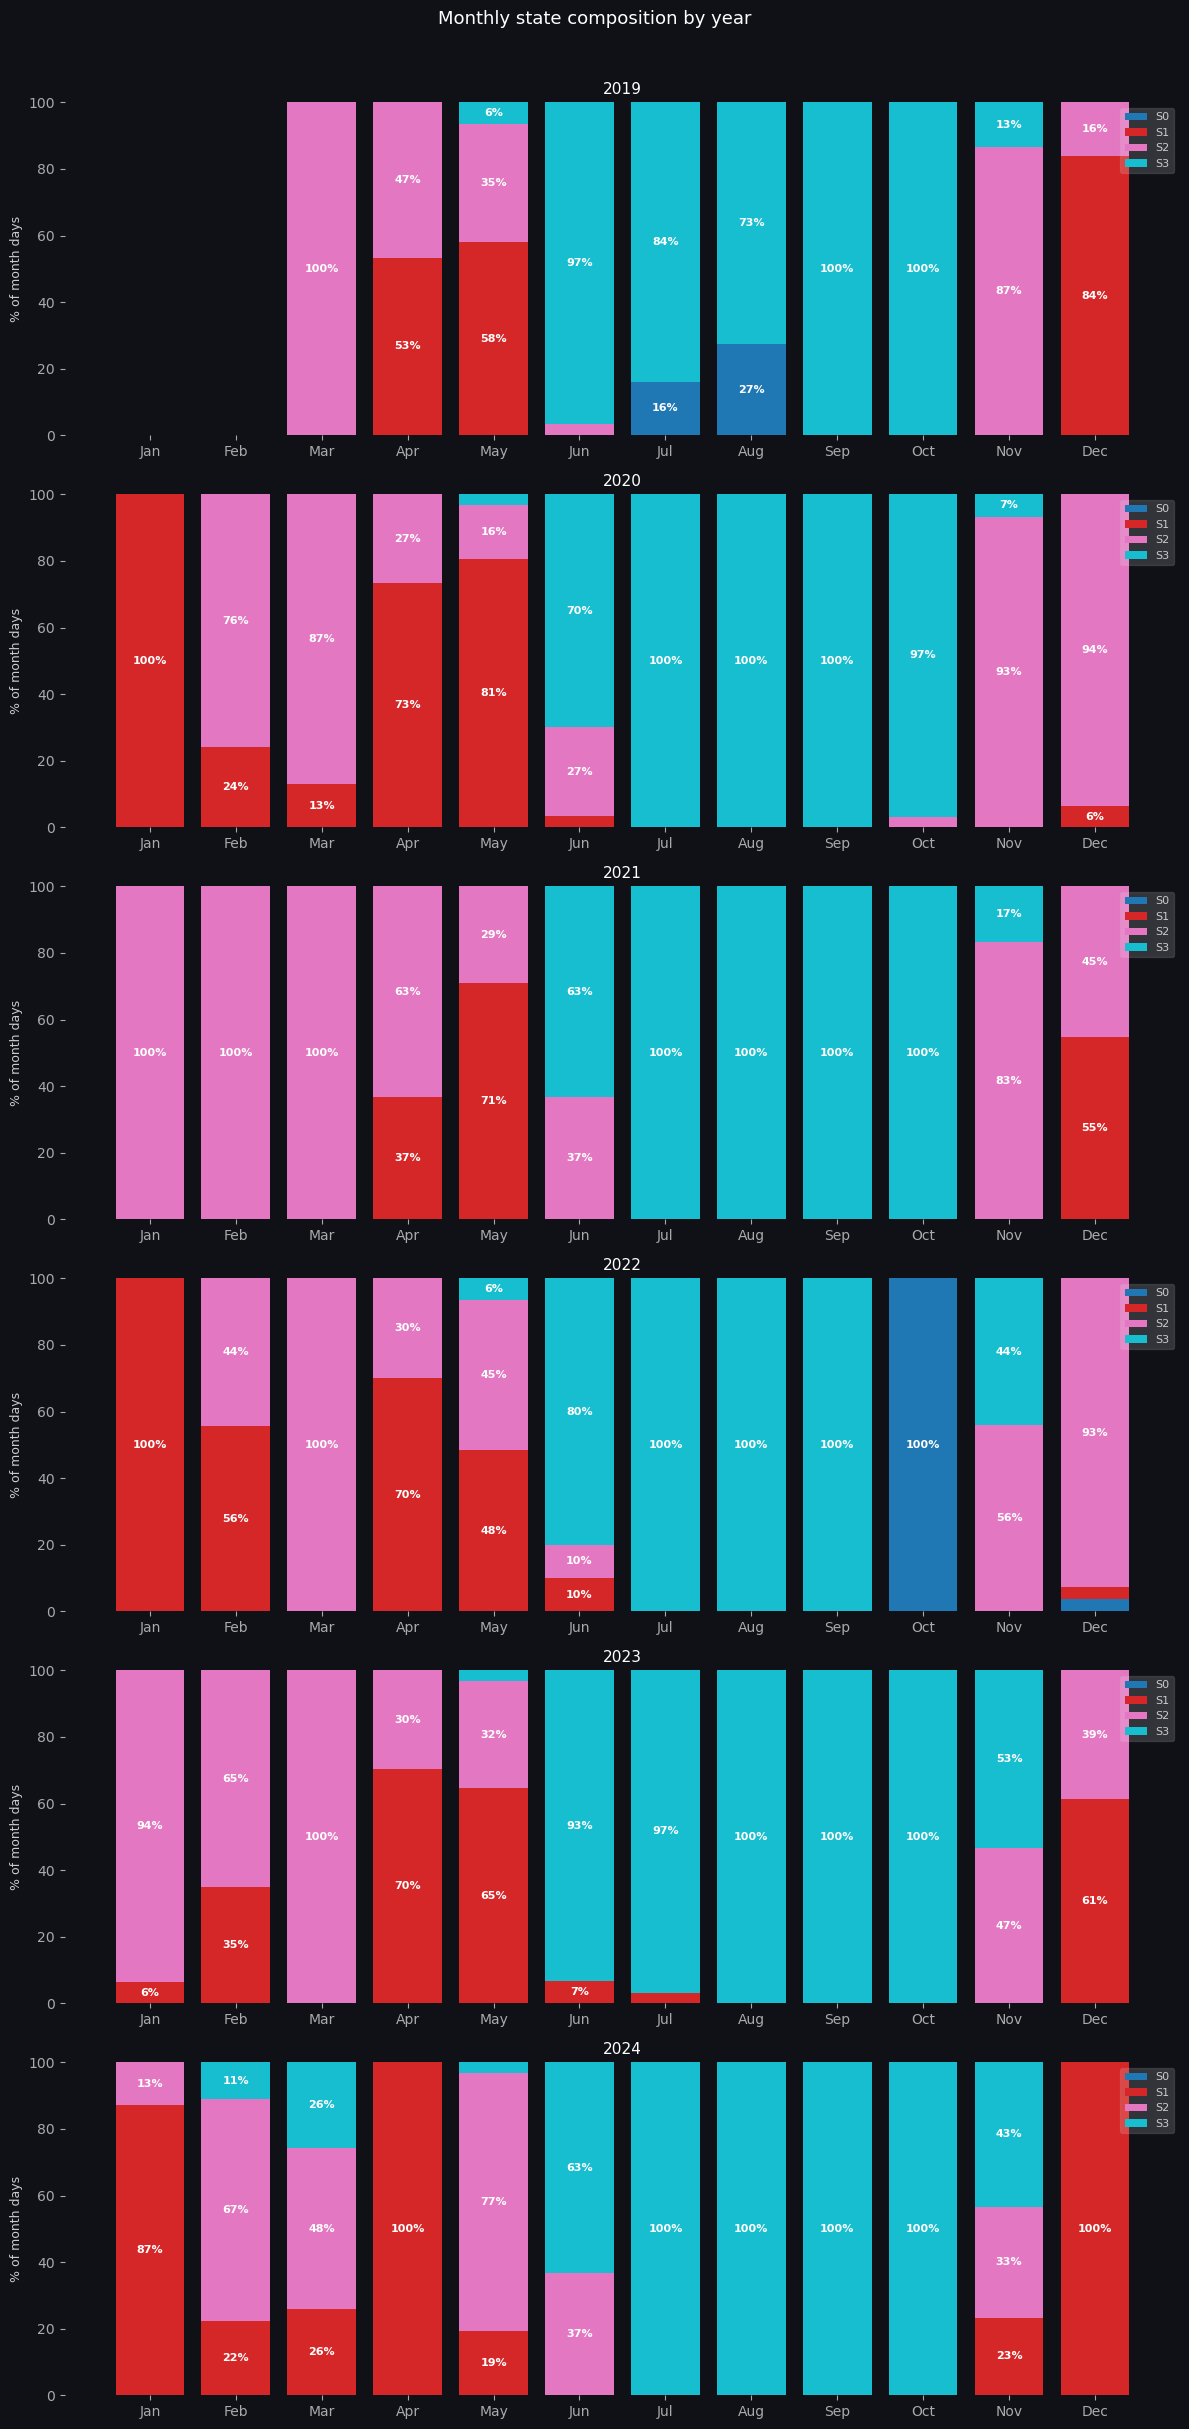

In [21]:
years = sorted(set(d.year for d in dates_real))

fig, axes = plt.subplots(len(years), 1, figsize=(12, 4 * len(years)), facecolor='#0f1117')
if len(years) == 1:
    axes = [axes]

for ax, year in zip(axes, years):
    ax.set_facecolor('#0f1117')
    year_mask = np.array([d.year == year for d in dates_real])

    month_state_yr = np.zeros((12, n_states), dtype=float)
    for i, m in enumerate(range(1, 13)):
        month_mask = year_mask & (months_real == m)
        if month_mask.sum() == 0:
            continue
        for k in range(n_states):
            month_state_yr[i, k] = 100 * np.mean((rbm_state == k)[month_mask])

    bottom = np.zeros(12)
    for k in range(n_states):
        vals = month_state_yr[:, k]
        ax.bar(month_names, vals, bottom=bottom,
               color=PAL[k], label=f'S{k}', edgecolor='none')
        for i, (v, b) in enumerate(zip(vals, bottom)):
            if v > 6:
                ax.text(i, b + v/2, f'{v:.0f}%', ha='center', va='center',
                        fontsize=8, color='white', fontweight='bold')
        bottom += vals

    ax.set_ylabel('% of month days', color='#cccccc', fontsize=9)
    ax.set_title(str(year), color='white', fontsize=11)
    ax.legend(loc='upper right', fontsize=8, framealpha=0.15, labelcolor='#cccccc')
    ax.tick_params(colors='#aaaaaa')
    ax.set_ylim(0, 100)
    for spine in ax.spines.values():
        spine.set_visible(False)

plt.suptitle('Monthly state composition by year', color='white', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### Full timeline of soft state membership: all years

The definitive visualization of the model output: a stacked bar chart showing daily soft-membership probability across all states for the entire 2019 to 2024 record.

Reading this plot:
- **Tall uniform bars** = the lake is confidently in one state
- **Mixed-colour bars** = transitional days between states  
- **Vertical white lines** = year boundaries
- **Month labels** (minor ticks) = help identify seasonal transitions

This is the key figure for the presentation: it shows the full ecological trajectory of Lake Greifen as discovered by the MixedRBM.

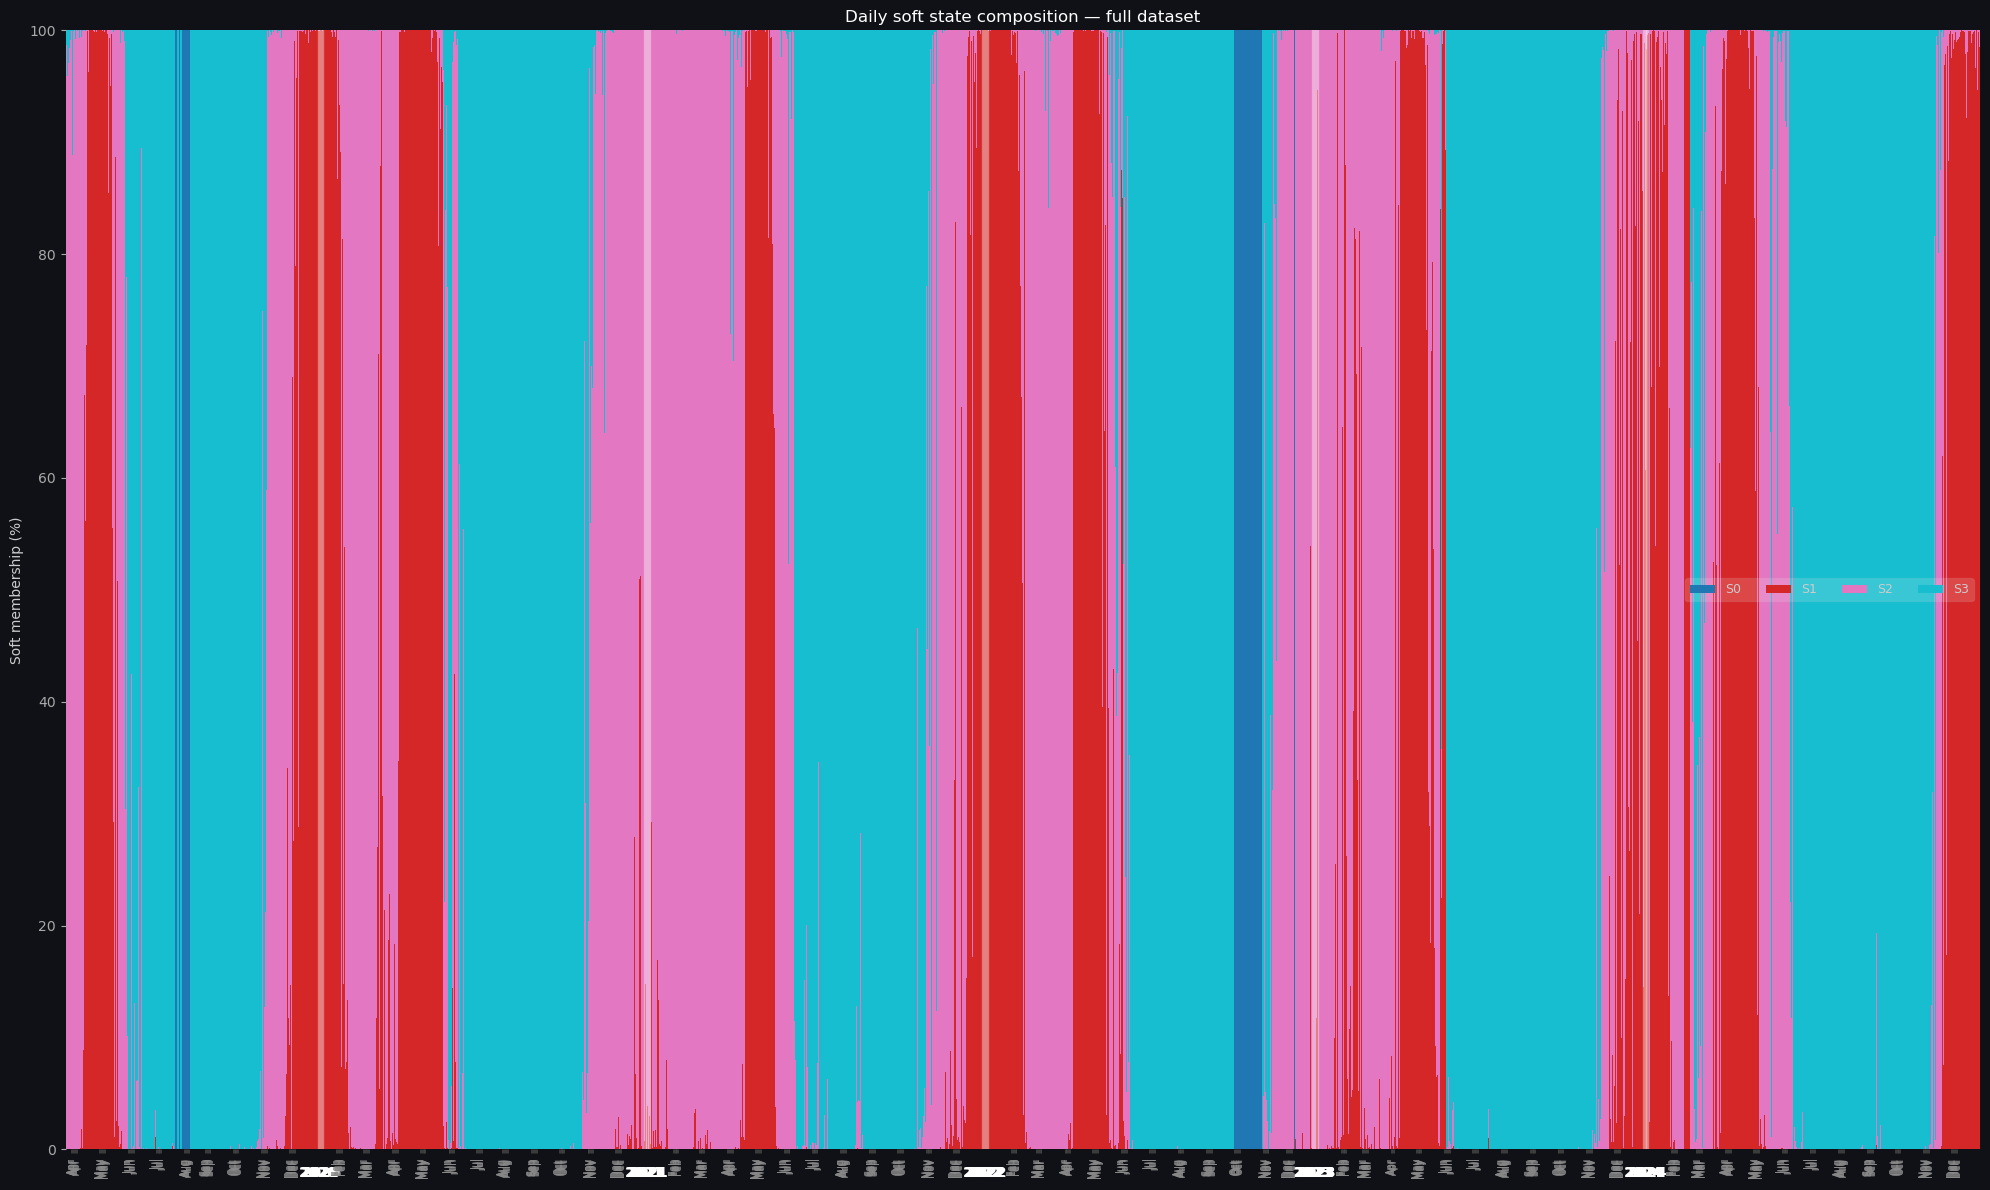

In [22]:
dists       = km_states.transform(H_both)
temperature = 0.05
soft_probs  = softmax(-dists / (dists.std() * temperature), axis=1)
 
fig, ax = plt.subplots(figsize=(20, 12), facecolor='#0f1117')
ax.set_facecolor('#0f1117')
 
day_idx = np.arange(len(dates_real))
bottom  = np.zeros(len(dates_real))
 
for k in range(n_states):
    vals = 100 * soft_probs[:, k]
    ax.bar(day_idx, vals, bottom=bottom, color=PAL[k],
           label=f'S{k}', edgecolor='none', width=1.0)
    bottom += vals
 
# ── Year lines + labels ───────────────────────────────────────────────────────
jan_pos = [i for i, d in enumerate(dates_real) if d.month == 1 and d.day <= 7]
for xi in jan_pos:
    ax.axvline(xi, color='#ffffff55', linewidth=1.0)
ax.set_xticks(jan_pos)
ax.set_xticklabels([str(dates_real[i].year) for i in jan_pos],
                   color='white', fontsize=10, fontweight='bold')
 
# ── Month tick marks + labels ─────────────────────────────────────────────────
mon_pos = [i for i, d in enumerate(dates_real) if d.day <= 7 and d.month != 1]
mon_lbl = [dates_real[i].strftime('%b') for i in mon_pos]
ax.set_xticks(mon_pos, minor=True)
ax.set_xticklabels(mon_lbl, minor=True, color='#888888', fontsize=7, rotation=90)
ax.tick_params(axis='x', which='minor', length=3, color='#444444')
ax.tick_params(axis='x', which='major', length=0, pad=12)
 
ax.set_ylabel('Soft membership (%)', color='#cccccc', fontsize=10)
ax.set_title('Daily soft state composition — full dataset', color='white', fontsize=12)
ax.legend(fontsize=9, framealpha=0.15, labelcolor='#cccccc', ncol=n_states)
ax.set_ylim(0, 100)
ax.set_xlim(0, len(dates_real))
ax.tick_params(axis='y', colors='#aaaaaa')
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.show()

### Dominant state intervals

For a selected target state, this extracts the contiguous calendar periods during which that state dominates (allowing up to 7-day gaps within a period). This produces a human-readable list of when the lake was in each regime: e.g. "Winter diatom state was dominant Feb 3  to  Mar 28, 2021 (53 days)." 

In [24]:
target_state = 0   

s3_dates = dates_real[rbm_state == target_state]

intervals = []
start = s3_dates[0]
prev  = s3_dates[0]

for d in s3_dates[1:]:
    if (d - prev).days > 7:
        intervals.append((start, prev))
        start = d
    prev = d
intervals.append((start, prev))

print(f"S{target_state} dominant intervals ({len(intervals)} periods):\n")
for i, (s, e) in enumerate(intervals):
    n_days = (rbm_state == target_state)[(dates_real >= s) & (dates_real <= e)].sum()
    print(f"  [{i+1:2d}]  {s.date()}  →  {e.date()}   ({n_days} days)")

S0 dominant intervals (3 periods):

  [ 1]  2019-07-22  →  2019-08-06   (11 days)
  [ 2]  2022-10-01  →  2022-10-31   (31 days)
  [ 3]  2022-12-10  →  2022-12-10   (1 days)


---
## 15. Anomaly Windows: Total Plankton Density

A sanity check: do the anomalous windows identified by the RBM correspond to visible spikes or dips in total plankton density? If yes, it confirms the model is picking up on real community-level signals, not noise in individual species channels.

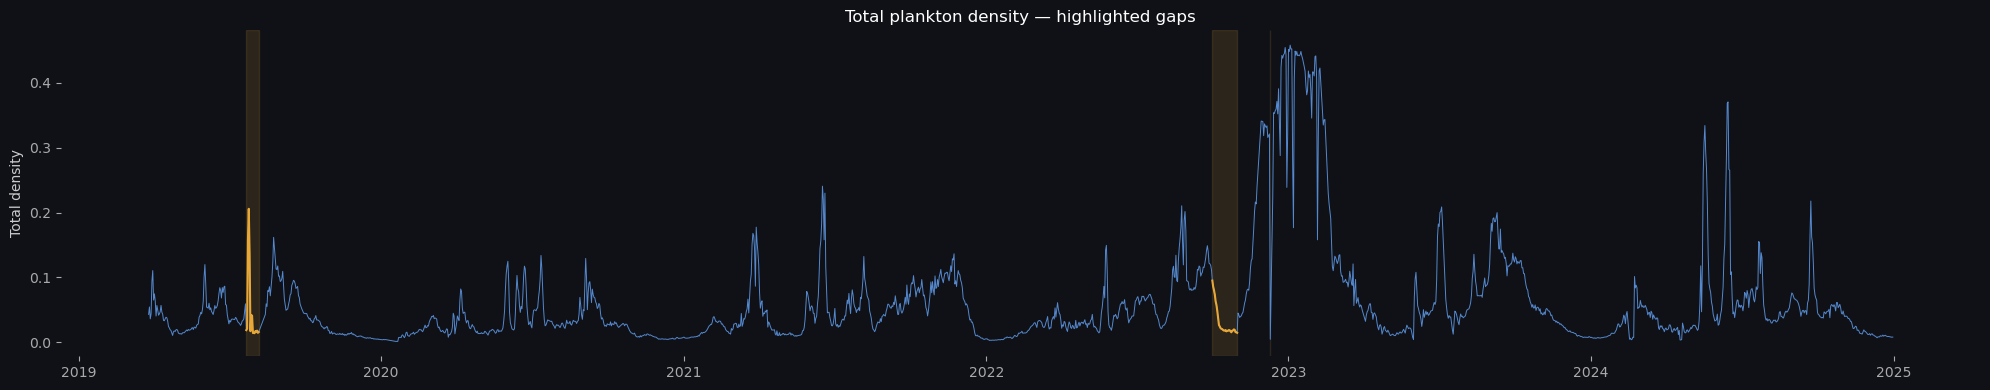

In [25]:
dates_idx     = pd.DatetimeIndex(dates)
total_density = real_den.sum(axis=1)
 
gap_ranges = [
    ('2019-07-22', '2019-08-06'),
    ('2022-10-01', '2022-10-31'),
    ('2022-12-10', '2022-12-10'),
]
 
fig, ax = plt.subplots(figsize=(20, 4), facecolor='#0f1117')
ax.set_facecolor('#0f1117')
 
ax.plot(dates_idx, total_density, color='#5588cc', linewidth=0.7, zorder=1)
 
for start, end in gap_ranges:
    mask = (dates_idx >= start) & (dates_idx <= end)
    ax.plot(dates_idx[mask], total_density[mask],
            color='#e8a838', linewidth=1.5, zorder=2)
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end),
               color='#e8a83822', zorder=0)
 
ax.set_ylabel('Total density', color='#cccccc')
ax.set_title('Total plankton density — highlighted gaps', color='white')
ax.tick_params(colors='#aaaaaa')
for spine in ax.spines.values():
    spine.set_visible(False)
 
plt.tight_layout()
plt.show()

### October 2022: Mean density of top enriched taxa

Plotting the mean density of the 15 taxa most enriched in October 2022 (relative to other Octobers) across the full time series. The highlighted window shows whether the enrichment is specific to that month or part of a longer trend.

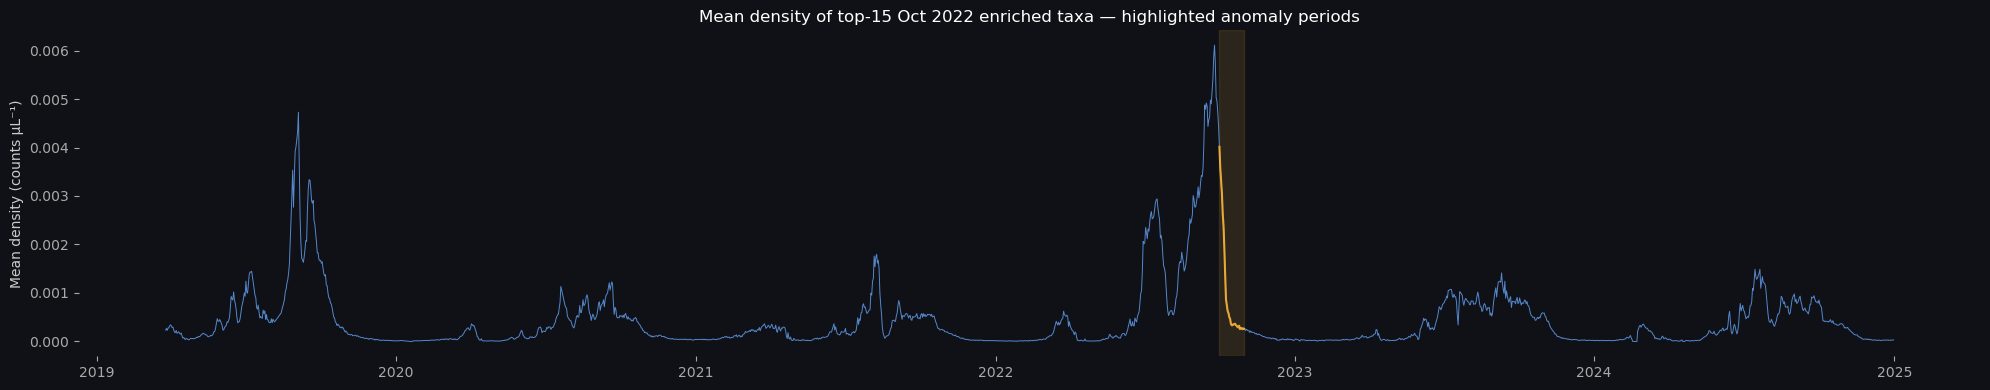

In [33]:
top15_oct = ['dinoflagellate_diamond', 'chroococcales', 'synedra',
             'cyanobacteria_colonial_clathrate', 'scenedesmus', 'chlorophyte_square',
             'askenasia', 'chlorophyte_frame', 'cyanobacteria_colonial_probably',
             'ciliate_green', 'planktosphaeria', 'plankton_z',
             'chlorophyte_colonial_dividing', 'vorticella_epistylis_like', 'staurastrum']

indices = [list(species).index(t) for t in top15_oct]
mean_density = real_den[:, indices].mean(axis=1)

gap_ranges = [
    ('2022-10-01', '2022-10-31')
]

fig, ax = plt.subplots(figsize=(20, 4), facecolor='#0f1117')
ax.set_facecolor('#0f1117')

ax.plot(dates_idx, mean_density, color='#5588cc', linewidth=0.7, zorder=1)

for start, end in gap_ranges:
    mask = (dates_idx >= start) & (dates_idx <= end)
    ax.plot(dates_idx[mask], mean_density[mask],
            color='#e8a838', linewidth=1.5, zorder=2)
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end),
               color='#e8a83822', zorder=0)

ax.set_ylabel('Mean density (counts µL⁻¹)', color='#cccccc')
ax.set_title('Mean density of top-15 Oct 2022 enriched taxa — highlighted anomaly periods', color='white')
ax.tick_params(colors='#aaaaaa')
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

### July to August 2019: Mean density of top enriched taxa

Same analysis for the July to August 2019 bloom window. The taxa list (rotifers, chrysophytes, cladocerans, cyanobacteria) is characteristic of a **stratified, warm, productive summer**: consistent with the known conditions during that period.

---
## Summary

| What the model learned | Ecological meaning |
|---|---|
| Hidden units in $W_b$ / $W_g$ | Species guilds that co-occur by presence and by abundance |
| K-means states on `H` | Recurring ecosystem regimes (winter mixing, spring bloom, summer stratification, anomalies) |
| State enrichment Δ | Indicator taxa for each regime |
| Soft membership timeline | Full ecological trajectory of the lake, 2019 to 2024 |
| Anomalous state assignments | Unsupervised detection of climate-driven community disruptions |

The MixedRBM successfully discovers interpretable ecological archetypes from raw species time series, without any external environmental variables: purely from the internal structure of the plankton community.

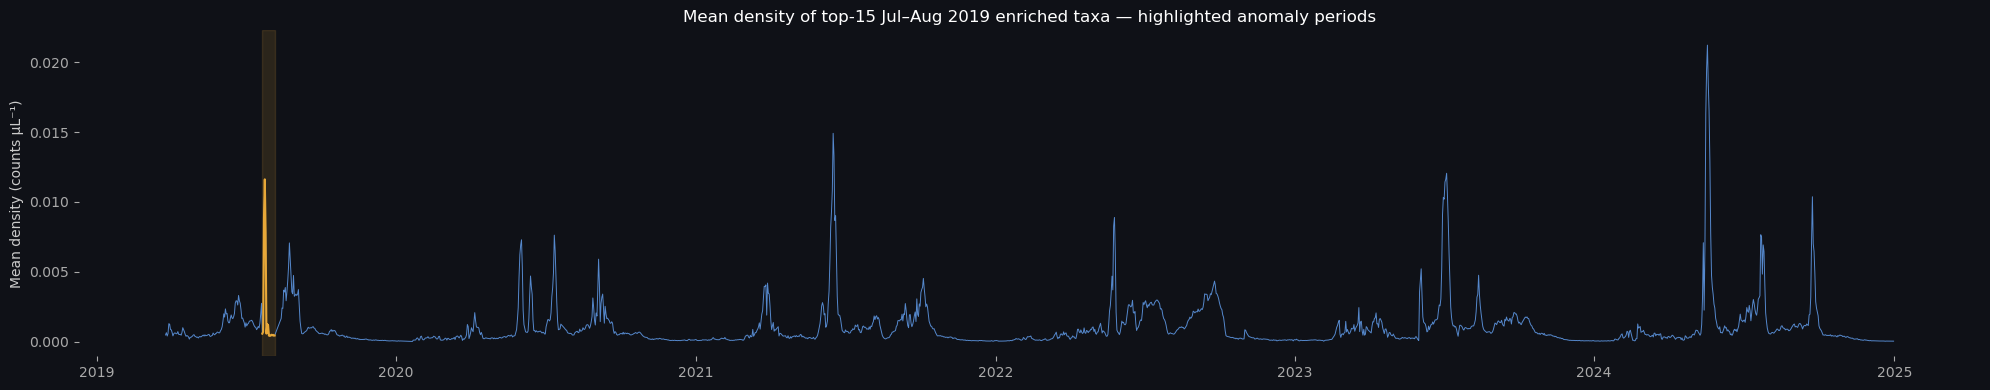

In [34]:
top15_jul = ['conochilus', 'dinobryon', 'coelastrum_reticulatum', 'trichocerca',
             'paradileptus', 'rotifer_long', 'diaphanosoma', 'rhodomonas',
             'chroococcales', 'chlorophyte_colonial_dividing', 'mallomonas_akrokomos',
             'chlorophyte_square', 'rotifer', 'cyanobacteria_colonial_blue', 'pediastrum']

indices = [list(species).index(t) for t in top15_jul]
mean_density = real_den[:, indices].mean(axis=1)

gap_ranges = [
    ('2019-07-22', '2019-08-06')
]

fig, ax = plt.subplots(figsize=(20, 4), facecolor='#0f1117')
ax.set_facecolor('#0f1117')

ax.plot(dates_idx, mean_density, color='#5588cc', linewidth=0.7, zorder=1)

for start, end in gap_ranges:
    mask = (dates_idx >= start) & (dates_idx <= end)
    ax.plot(dates_idx[mask], mean_density[mask],
            color='#e8a838', linewidth=1.5, zorder=2)
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end),
               color='#e8a83822', zorder=0)

ax.set_ylabel('Mean density (counts µL⁻¹)', color='#cccccc')
ax.set_title('Mean density of top-15 Jul–Aug 2019 enriched taxa — highlighted anomaly periods', color='white')
ax.tick_params(colors='#aaaaaa')
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()